In [33]:
# ============================================================
# OHRC ↔ TMC-2 CORRESPONDENCE MODEL
# CELL 1 — UNIFIED ENVIRONMENT SETUP
# ============================================================

import importlib
import subprocess
import sys
import os
import json
import warnings
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Any

# ------------------------------------------------------------
# Install only missing packages
# ------------------------------------------------------------

_REQUIRED = [
    "numpy",
    "pandas",
    "scipy",
    "sklearn",
    "matplotlib",
    "torch",
    "torchvision",
]

_PIP_NAMES = {
    "sklearn": "scikit-learn",
}

_missing = [
    package
    for package in _REQUIRED
    if importlib.util.find_spec(package) is None
]

if _missing:

    pip_names = [
        _PIP_NAMES.get(package, package)
        for package in _missing
    ]

    print(
        f"Installing missing packages: {pip_names}"
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *pip_names,
        ]
    )

else:

    print(
        "All required packages already installed."
    )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from scipy.spatial import cKDTree

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RNG_SEED = 42

np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ------------------------------------------------------------
# Project directories
#
# These are the FINALIZED upstream products.
#
# OHRC preprocessing + encoder:
#     D:\ISRO\OHRC_tiles
#
# TMC-2 preprocessing + encoder:
#     D:\ISRO\TMC_tiles
#
# The correspondence model does NOT preprocess or
# re-encode the raw OHRC/TMC-2 data.
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"D:\ISRO"
)

OHRC_DIR = (
    PROJECT_ROOT /
    "OHRC_tiles"
)

TMC2_DIR = (
    PROJECT_ROOT /
    "TMC_tiles"
)

# ------------------------------------------------------------
# Correspondence-model outputs
# ------------------------------------------------------------

CORRESPONDENCE_OUT = (
    PROJECT_ROOT /
    "OHRC_TMC2_correspondence"
)

PAIRS_DIR = (
    CORRESPONDENCE_OUT /
    "pairs"
)

MODELS_DIR = (
    CORRESPONDENCE_OUT /
    "models"
)

EVAL_DIR = (
    CORRESPONDENCE_OUT /
    "evaluation"
)

PREDICTIONS_DIR = (
    CORRESPONDENCE_OUT /
    "predictions"
)

for directory in [
    CORRESPONDENCE_OUT,
    PAIRS_DIR,
    MODELS_DIR,
    EVAL_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Basic correspondence configuration
# ------------------------------------------------------------

EMBED_DIM = 256

# Maximum geolocation distance for candidate
# OHRC ↔ TMC-2 correspondence pairs.
#
# This is a candidate-generation threshold,
# NOT a claim that every pair within this distance
# is exact ground truth.
MAX_PAIR_DISTANCE_M = 300.0

# Number of nearest TMC-2 candidates retained
# for each OHRC embedding.
TOP_K_CANDIDATES = 5

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

EPOCHS = 50

WEIGHT_DECAY = 1e-5

TEMPERATURE = 0.07

# ------------------------------------------------------------
# Evaluation configuration
# ------------------------------------------------------------

TOP_K_RETRIEVAL = (
    1,
    5,
    10,
)

# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 70)
print("OHRC ↔ TMC-2 CORRESPONDENCE MODEL")
print("=" * 70)

print(
    f"Project root       : {PROJECT_ROOT}"
)

print(
    f"OHRC embeddings    : {OHRC_DIR}"
)

print(
    f"TMC-2 embeddings   : {TMC2_DIR}"
)

print(
    f"Correspondence out : {CORRESPONDENCE_OUT}"
)

print(
    f"Embedding dimension: {EMBED_DIM}"
)

print(
    f"Device             : {DEVICE}"
)

print("=" * 70)

All required packages already installed.
OHRC ↔ TMC-2 CORRESPONDENCE MODEL
Project root       : D:\ISRO
OHRC embeddings    : D:\ISRO\OHRC_tiles
TMC-2 embeddings   : D:\ISRO\TMC_tiles
Correspondence out : D:\ISRO\OHRC_TMC2_correspondence
Embedding dimension: 256
Device             : cpu


In [34]:
# ============================================================
# CELL 2 — FINALIZED REPRESENTATION CONFIGURATION
# ============================================================
#
# This notebook consumes the outputs of the finalized
# OHRC and TMC-2 preprocessing + encoder pipelines.
#
# IMPORTANT:
# No raw OHRC/TMC-2 preprocessing is performed here.
# No OHRC/TMC-2 image encoder is rebuilt here.
#
# Expected upstream outputs:
#
#     D:\ISRO\OHRC_tiles
#     D:\ISRO\TMC_tiles
#
# The correspondence model operates on the finalized
# 256-D embeddings produced by those pipelines.
# ============================================================

# ------------------------------------------------------------
# Embedding configuration
# ------------------------------------------------------------

EMBED_DIM = 256

# ------------------------------------------------------------
# Upstream product roots
# ------------------------------------------------------------

OHRC_EMBEDDING_ROOT = OHRC_DIR

TMC2_EMBEDDING_ROOT = TMC2_DIR

# ------------------------------------------------------------
# Required representation
# ------------------------------------------------------------

OHRC_EMBEDDING_COLUMN = "ohrc_embedding_256"

TMC2_EMBEDDING_COLUMN = "tmc2_embedding_256"

# ------------------------------------------------------------
# Metadata required for spatial correspondence
# ------------------------------------------------------------

REQUIRED_SPATIAL_COLUMNS = [
    "latitude",
    "longitude",
]

# ------------------------------------------------------------
# Candidate correspondence settings
# ------------------------------------------------------------

MAX_PAIR_DISTANCE_M = 300.0

TOP_K_CANDIDATES = 5

# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 70)
print("FINALIZED REPRESENTATION CONFIGURATION")
print("=" * 70)

print(
    f"OHRC output root : {OHRC_EMBEDDING_ROOT}"
)

print(
    f"TMC-2 output root: {TMC2_EMBEDDING_ROOT}"
)

print(
    f"Embedding dim    : {EMBED_DIM}"
)

print(
    f"OHRC embedding   : {OHRC_EMBEDDING_COLUMN}"
)

print(
    f"TMC-2 embedding  : {TMC2_EMBEDDING_COLUMN}"
)

print(
    f"Max pair distance: {MAX_PAIR_DISTANCE_M} m"
)

print(
    f"Top-K candidates : {TOP_K_CANDIDATES}"
)

print("=" * 70)

FINALIZED REPRESENTATION CONFIGURATION
OHRC output root : D:\ISRO\OHRC_tiles
TMC-2 output root: D:\ISRO\TMC_tiles
Embedding dim    : 256
OHRC embedding   : ohrc_embedding_256
TMC-2 embedding  : tmc2_embedding_256
Max pair distance: 300.0 m
Top-K candidates : 5


In [3]:
OHRC_NAME_RE = re.compile(
    r"ch2_ohr_(?P<mode>[a-z0-9]+)_(?P<stamp>\d{8}T\d{10})_d_img_[a-z0-9]+",
    re.IGNORECASE,
)

def parse_acquisition_from_name(name: str) -> Optional[datetime]:
    m = OHRC_NAME_RE.search(os.path.basename(name))
    if not m:
        return None
    # stamp format YYYYMMDDTHHMMSSssss, where ssss are 1/10 ms (100 us)
    stamp = m.group("stamp")
    base = datetime.strptime(stamp[:15], "%Y%m%dT%H%M%S")
    frac4 = int(stamp[15:19])
    return base.replace(microsecond=frac4 * 100)

def is_calibrated_name(name: str) -> bool:
    m = OHRC_NAME_RE.search(os.path.basename(name))
    return bool(m and "ncp" in m.group("mode").lower())

def select_2026_latest_three_months(zip_root=ZIP_ROOT, start=START_DATE, end=END_DATE,
                                     calibrated_only=True) -> pd.DataFrame:
    start_dt = datetime.fromisoformat(start)
    end_dt = datetime.fromisoformat(end + "T23:59:59.999999")
    rows = []
    for p in glob.glob(os.path.join(zip_root, "**", "*.zip"), recursive=True):
        dt = parse_acquisition_from_name(p)
        if dt is None or not (start_dt <= dt <= end_dt):
            continue
        if calibrated_only and not is_calibrated_name(p):
            continue
        rows.append({"zip_path": p, "acquisition_utc": dt.isoformat(),
                     "calibrated": is_calibrated_name(p)})
    return pd.DataFrame(rows).sort_values("acquisition_utc") if rows else pd.DataFrame(
        columns=["zip_path", "acquisition_utc", "calibrated"])

# Example after downloads are present:
# selected = select_2026_latest_three_months()
# print("Selected ZIPs:", len(selected))
# display(selected.head())


NameError: name 'ZIP_ROOT' is not defined

In [35]:
# ============================================================
# CELL 3 — DISCOVER FINALIZED OHRC / TMC-2 OUTPUTS
# ============================================================
#
# This cell does NOT inspect raw products.
#
# It searches the finalized output directories produced by
# the frozen OHRC and TMC-2 preprocessing + encoder pipelines.
# ============================================================

def list_candidate_files(
    root: Path,
    extensions: Tuple[str, ...] = (
        ".csv",
        ".npz",
        ".pt",
        ".pth",
    ),
) -> List[Path]:

    if not root.exists():

        print(
            f"[WARN] Directory does not exist: {root}"
        )

        return []

    files = []

    for path in root.rglob("*"):

        if (
            path.is_file()
            and path.suffix.lower() in extensions
        ):

            files.append(path)

    return sorted(files)


# ------------------------------------------------------------
# Discover OHRC outputs
# ------------------------------------------------------------

ohrc_files = list_candidate_files(
    OHRC_EMBEDDING_ROOT
)

print("=" * 70)
print("OHRC FINALIZED OUTPUTS")
print("=" * 70)

if ohrc_files:

    for path in ohrc_files:

        print(
            path.relative_to(
                OHRC_EMBEDDING_ROOT
            )
        )

else:

    print(
        "[WARN] No candidate OHRC output files found."
    )


# ------------------------------------------------------------
# Discover TMC-2 outputs
# ------------------------------------------------------------

tmc2_files = list_candidate_files(
    TMC2_EMBEDDING_ROOT
)

print("\n" + "=" * 70)
print("TMC-2 FINALIZED OUTPUTS")
print("=" * 70)

if tmc2_files:

    for path in tmc2_files:

        print(
            path.relative_to(
                TMC2_EMBEDDING_ROOT
            )
        )

else:

    print(
        "[WARN] No candidate TMC-2 output files found."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISCOVERY SUMMARY")
print("=" * 70)

print(
    f"OHRC candidate files : {len(ohrc_files)}"
)

print(
    f"TMC-2 candidate files: {len(tmc2_files)}"
)

print("=" * 70)

OHRC FINALIZED OUTPUTS
ohrc_manifest.csv

TMC-2 FINALIZED OUTPUTS
mvp_embeddings.npz
mvp_embeddings_manifest.csv
mvp_manifest.csv
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000000_c003584.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000768_c002304.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001024_c001024.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001280_c001792.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001280_c003072.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001536_c002048.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001792_c000256.npz
mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_

In [4]:
# ============================================================
# CELL 4 — VERIFY FINALIZED OHRC / TMC-2 DATA ROOTS
# ============================================================
#
# The correspondence model works only with finalized outputs.
#
# OHRC XML/PDS4 parsing is intentionally NOT performed here.
# TMC-2 XML/PDS4 parsing is intentionally NOT performed here.
#
# Those operations belong to the finalized preprocessing
# pipelines.
# ============================================================

def verify_output_root(
    name: str,
    root: Path
) -> None:

    print(
        f"\n{name}"
    )

    print(
        "-" * 70
    )

    print(
        f"Path: {root}"
    )

    if not root.exists():

        print(
            "[ERROR] Output directory does not exist."
        )

        return

    if not root.is_dir():

        print(
            "[ERROR] Path exists but is not a directory."
        )

        return

    files = [
        p
        for p in root.rglob("*")
        if p.is_file()
    ]

    print(
        f"[OK] Directory exists."
    )

    print(
        f"Files found: {len(files)}"
    )

    # Show a small sample only.
    for path in files[:15]:

        print(
            "  ",
            path.relative_to(root)
        )

    if len(files) > 15:

        print(
            f"  ... and {len(files) - 15} more"
        )


# ------------------------------------------------------------
# Verify finalized OHRC outputs
# ------------------------------------------------------------

verify_output_root(
    "OHRC FINALIZED OUTPUT",
    OHRC_EMBEDDING_ROOT
)


# ------------------------------------------------------------
# Verify finalized TMC-2 outputs
# ------------------------------------------------------------

verify_output_root(
    "TMC-2 FINALIZED OUTPUT",
    TMC2_EMBEDDING_ROOT
)


print(
    "\n" + "=" * 70
)

print(
    "UPSTREAM OUTPUT VERIFICATION COMPLETE"
)

print(
    "=" * 70
)


OHRC FINALIZED OUTPUT
----------------------------------------------------------------------
Path: D:\ISRO\OHRC_tiles
[OK] Directory exists.
Files found: 1801
   ohrc_manifest.csv
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c002_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c002_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c003_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_

In [36]:
# ============================================================
# CELL 5 — CHECK FINALIZED EMBEDDING ARTIFACTS
# ============================================================
#
# The OHRC ↔ TMC-2 correspondence model operates on the
# finalized 256-D embeddings and their associated metadata.
#
# Raw OHRC image loading, memmapping, orientation correction,
# and cropping are intentionally NOT performed here.
# ============================================================

def summarize_artifacts(
    name: str,
    root: Path
) -> None:

    print("\n" + "=" * 70)
    print(f"{name} ARTIFACTS")
    print("=" * 70)

    if not root.exists():

        print(
            f"[ERROR] Directory does not exist: {root}"
        )

        return

    files = sorted(
        p
        for p in root.rglob("*")
        if p.is_file()
    )

    if not files:

        print(
            "[WARN] No files found."
        )

        return

    # Group files by extension.
    extension_counts = {}

    for path in files:

        ext = (
            path.suffix.lower()
            if path.suffix
            else "[no extension]"
        )

        extension_counts[ext] = (
            extension_counts.get(ext, 0) + 1
        )

    print(
        f"Total files: {len(files)}"
    )

    print(
        "\nFile types:"
    )

    for ext, count in sorted(
        extension_counts.items()
    ):

        print(
            f"  {ext:12s} : {count}"
        )

    print(
        "\nSample files:"
    )

    for path in files[:20]:

        print(
            "  ",
            path.relative_to(root)
        )

    if len(files) > 20:

        print(
            f"  ... and {len(files) - 20} more"
        )


# ------------------------------------------------------------
# OHRC
# ------------------------------------------------------------

summarize_artifacts(
    "OHRC",
    OHRC_EMBEDDING_ROOT
)


# ------------------------------------------------------------
# TMC-2
# ------------------------------------------------------------

summarize_artifacts(
    "TMC-2",
    TMC2_EMBEDDING_ROOT
)


print(
    "\n" + "=" * 70
)

print(
    "ARTIFACT INSPECTION COMPLETE"
)

print(
    "=" * 70
)


OHRC ARTIFACTS
Total files: 1801

File types:
  .csv         : 1
  .jpg         : 1800

Sample files:
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c002_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c002_structural.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c003_illum.jpg
   ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c003_structural.jpg
   ch

In [6]:
# ============================================================
# CELL 6 — EMBEDDING ARTIFACT DISCOVERY HELPERS
# ============================================================
#
# The correspondence model consumes finalized 256-D embeddings.
#
# No raw OHRC DN → radiance conversion is performed here.
# No TDI/Max_SR assumptions are made here.
# No image normalization is performed here.
# No saturation calculation is performed here.
#
# Those operations belong exclusively to the finalized OHRC
# preprocessing pipeline.
# ============================================================

def find_files_by_name_patterns(
    root: Path,
    patterns: List[str]
) -> List[Path]:

    matches = []

    if not root.exists():
        return matches

    for pattern in patterns:

        matches.extend(
            root.rglob(pattern)
        )

    # Remove duplicates while preserving sorted order.
    return sorted(
        set(
            path
            for path in matches
            if path.is_file()
        )
    )


def print_candidate_artifacts(
    name: str,
    root: Path,
    patterns: List[str]
) -> List[Path]:

    matches = find_files_by_name_patterns(
        root,
        patterns
    )

    print(
        f"\n{name}"
    )

    print(
        "-" * 70
    )

    if not matches:

        print(
            "[WARN] No matching artifacts found."
        )

        return []

    for path in matches:

        try:
            relative = path.relative_to(root)
        except ValueError:
            relative = path

        print(
            "  ",
            relative
        )

    print(
        f"Found {len(matches)} candidate artifact(s)."
    )

    return matches


# ------------------------------------------------------------
# Search for likely OHRC embedding artifacts
# ------------------------------------------------------------

ohrc_embedding_candidates = print_candidate_artifacts(
    "OHRC EMBEDDING CANDIDATES",
    OHRC_EMBEDDING_ROOT,
    [
        "*embedding*.npz",
        "*embedding*.csv",
        "*embeddings*.npz",
        "*embeddings*.csv",
        "*manifest*.csv",
    ],
)


# ------------------------------------------------------------
# Search for likely TMC-2 embedding artifacts
# ------------------------------------------------------------

tmc2_embedding_candidates = print_candidate_artifacts(
    "TMC-2 EMBEDDING CANDIDATES",
    TMC2_EMBEDDING_ROOT,
    [
        "*embedding*.npz",
        "*embedding*.csv",
        "*embeddings*.npz",
        "*embeddings*.csv",
        "*manifest*.csv",
    ],
)


print(
    "\n" + "=" * 70
)

print(
    "EMBEDDING ARTIFACT DISCOVERY COMPLETE"
)

print(
    "=" * 70
)


OHRC EMBEDDING CANDIDATES
----------------------------------------------------------------------
   ohrc_manifest.csv
Found 1 candidate artifact(s).

TMC-2 EMBEDDING CANDIDATES
----------------------------------------------------------------------
[WARN] No matching artifacts found.

EMBEDDING ARTIFACT DISCOVERY COMPLETE


In [37]:
# CELL 7 — FINALIZED EMBEDDING METADATA VALIDATION
# No raw OHRC geometry interpolation is performed here.
# Geolocation must come from the finalized OHRC/TMC-2 embedding metadata.

def validate_spatial_metadata(df, name):
    required = ["latitude", "longitude"]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"{name} metadata is missing required spatial columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    out = df.copy()

    out["latitude"] = pd.to_numeric(out["latitude"], errors="coerce")
    out["longitude"] = pd.to_numeric(out["longitude"], errors="coerce")

    valid = (
        out["latitude"].notna()
        & out["longitude"].notna()
        & out["latitude"].between(-90, 90)
        & out["longitude"].between(-180, 180)
    )

    print(f"{name}:")
    print(f"  total records       : {len(out)}")
    print(f"  valid lat/lon       : {int(valid.sum())}")
    print(f"  invalid/missing     : {int((~valid).sum())}")

    if valid.sum() == 0:
        raise ValueError(f"{name}: no valid latitude/longitude records found.")

    return out, valid


print("Spatial metadata validation helper ready.")
print("Raw OHRC geometry interpolation is intentionally disabled.")

Spatial metadata validation helper ready.
Raw OHRC geometry interpolation is intentionally disabled.


In [ ]:
@dataclass
class OHRCPatchMeta:
    source_scene_id: str
    source_zip: str
    acquisition_utc: Optional[str]
    tile_row: int
    tile_col: int
    native_r0: int
    native_c0: int
    native_size_px: int
    encoder_size_px: int
    ground_footprint_m: float
    resolution_m_per_px: float
    lat: float
    lon: float
    sun_azimuth: float
    sun_elevation: float
    solar_incidence: float
    tdi_stages: str
    bits_selection: str
    orbit_limb_direction: str
    spacecraft_yaw_direction: str
    saturation_fraction: float
    structural_jpeg: str
    illumination_jpeg: str


def save_gray_jpeg(unit_img: np.ndarray, path: str, size=ENCODER_SIZE, quality=JPEG_QUALITY):
    u8 = (np.clip(unit_img, 0, 1) * 255.0 + 0.5).astype(np.uint8)
    im = Image.fromarray(u8, mode="L")
    if im.size != (size, size):
        im = im.resize((size, size), resample=Image.Resampling.LANCZOS)
    im.save(path, format="JPEG", quality=quality, subsampling=0, optimize=True)


def tile_ohrc_scene(mm: np.ndarray, meta: dict, geo: Optional[OHRCGeoGrid], scene_id: str,
                    source_zip: str, out_dir: str,
                    target_ground_m=TARGET_GROUND_FOOTPRINT_M,
                    stride_fraction=STRIDE_FRACTION) -> List[dict]:
    gsd = float(meta.get("pixel_resolution_m", 0.25))
    if not np.isfinite(gsd) or gsd <= 0: gsd = 0.25
    native = max(256, int(round(target_ground_m / gsd)))
    native = min(native, mm.shape[0], mm.shape[1])
    stride = max(1, int(round(native * stride_fraction)))
    H, W = mm.shape
    os.makedirs(out_dir, exist_ok=True)
    rows=[]; tr=0
    for r0 in range(0, max(H-native+1, 1), stride):
        tc=0
        for c0 in range(0, max(W-native+1, 1), stride):
            dn = crop_oriented(mm, r0, c0, native, native, meta)
            if dn.shape != (native, native):
                continue
            sat = saturation_fraction(dn)
            if sat > OHRC_MAX_SATURATION_FRACTION:
                tc += 1
                continue
            structural, _, _ = ohrc_robust_unit_range(dn)
            illum = ohrc_illumination_invariant_weber(structural)

            lat=lon=float("nan")
            if geo is not None:
                try:
                    # Geo CSV addresses stored raster scan/pixel. Convert oriented center back.
                    cr, cc = r0 + native/2, c0 + native/2
                    rev_r, rev_c = ohrc_orientation_ops(meta)
                    scan = (H - 1 - cr) if rev_r else cr
                    pixel = (W - 1 - cc) if rev_c else cc
                    lat, lon = geo.at(pixel, scan)
                except Exception:
                    pass

            stem = f"{scene_id}_r{tr:05d}_c{tc:03d}"
            p_struct = os.path.join(out_dir, stem + "_structural.jpg")
            p_illum = os.path.join(out_dir, stem + "_illum.jpg")
            save_gray_jpeg(structural, p_struct)
            save_gray_jpeg(illum, p_illum)

            rows.append(asdict(OHRCPatchMeta(
                source_scene_id=scene_id, source_zip=os.path.basename(source_zip),
                acquisition_utc=meta.get("start_date_time"), tile_row=tr, tile_col=tc,
                native_r0=r0, native_c0=c0, native_size_px=native,
                encoder_size_px=ENCODER_SIZE, ground_footprint_m=native*gsd,
                resolution_m_per_px=gsd, lat=lat, lon=lon,
                sun_azimuth=float(meta.get("sun_azimuth", np.nan)),
                sun_elevation=float(meta.get("sun_elevation", np.nan)),
                solar_incidence=float(meta.get("solar_incidence", np.nan)),
                tdi_stages=str(meta.get("tdi_stages", "")), bits_selection=str(meta.get("bits_selection", "")),
                orbit_limb_direction=str(meta.get("orbit_limb_direction", "")),
                spacecraft_yaw_direction=str(meta.get("spacecraft_yaw_direction", "")),
                saturation_fraction=sat, structural_jpeg=p_struct, illumination_jpeg=p_illum,
            )))
            tc += 1
        tr += 1
    return rows


In [38]:
# CELL 8 — INSPECT FINALIZED EMBEDDING ARTIFACTS
# The correspondence model works only with finalized OHRC/TMC-2
# embeddings and their associated metadata.

def inspect_artifact(path, name):
    path = Path(path)

    print(f"\n{'=' * 70}")
    print(f"{name}")
    print(f"{'=' * 70}")
    print(f"Path: {path}")
    print(f"Exists: {path.exists()}")

    if not path.exists():
        return

    print(f"Size: {path.stat().st_size / (1024 ** 2):.2f} MB")

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path, nrows=5)

        print(f"Type: CSV")
        print(f"Columns ({len(df.columns)}):")
        print(list(df.columns))

        print("\nPreview:")
        display(df.head())

    elif path.suffix.lower() == ".npz":
        data = np.load(path, allow_pickle=True)

        print(f"Type: NPZ")
        print("Arrays:")
        for key in data.files:
            arr = data[key]
            print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

    elif path.suffix.lower() in {".pt", ".pth"}:
        obj = torch.load(path, map_location="cpu", weights_only=False)

        print(f"Type: PyTorch")
        if isinstance(obj, dict):
            print("Keys:")
            for key, value in obj.items():
                if hasattr(value, "shape"):
                    print(f"  {key}: shape={tuple(value.shape)}")
                else:
                    print(f"  {key}: {type(value).__name__}")
        else:
            print(f"Object type: {type(obj).__name__}")

    else:
        print("Unsupported artifact type for automatic inspection.")


print("Finalized embedding artifact inspection helper ready.")
print("No raw OHRC scene discovery is performed in this notebook.")

Finalized embedding artifact inspection helper ready.
No raw OHRC scene discovery is performed in this notebook.


In [39]:
# CELL 9 — INSPECT FINALIZED OHRC/TMC-2 MANIFESTS

def inspect_manifest(path, sensor_name):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"{sensor_name} manifest not found: {path}")

    df = pd.read_csv(path)

    print("\n" + "=" * 80)
    print(f"{sensor_name} FINALIZED MANIFEST")
    print("=" * 80)
    print(f"Path: {path}")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    print("\nColumns:")
    for i, col in enumerate(df.columns):
        print(f"  [{i:02d}] {col}")

    print("\nFirst 5 rows:")
    display(df.head())

    return df


# OHRC manifest was discovered by Cell 5.
ohrc_manifest_candidates = [
    Path(p) for p in ohrc_embedding_candidates
    if Path(p).name.lower() == "ohrc_manifest.csv"
]

if not ohrc_manifest_candidates:
    ohrc_manifest_candidates = [
        Path(p) for p in ohrc_embedding_candidates
        if "manifest" in Path(p).name.lower()
        and Path(p).suffix.lower() == ".csv"
    ]

if not ohrc_manifest_candidates:
    raise FileNotFoundError(
        "No OHRC manifest was found among the discovered artifacts."
    )

OHRC_MANIFEST_PATH = ohrc_manifest_candidates[0]

OHRC_MANIFEST_DF = inspect_manifest(
    OHRC_MANIFEST_PATH,
    "OHRC"
)


# Find TMC-2 manifest independently.
tmc2_manifest_candidates = [
    Path(p) for p in tmc2_embedding_candidates
    if "manifest" in Path(p).name.lower()
    and Path(p).suffix.lower() == ".csv"
]

if tmc2_manifest_candidates:
    TMC2_MANIFEST_PATH = tmc2_manifest_candidates[0]

    TMC2_MANIFEST_DF = inspect_manifest(
        TMC2_MANIFEST_PATH,
        "TMC-2"
    )
else:
    TMC2_MANIFEST_PATH = None
    TMC2_MANIFEST_DF = None

    print("\n[INFO] No TMC-2 manifest was found in the current candidate list.")


OHRC FINALIZED MANIFEST
Path: D:\ISRO\OHRC_tiles\ohrc_manifest.csv
Rows: 900
Columns: 23

Columns:
  [00] source_scene_id
  [01] source_scene_root
  [02] acquisition_utc
  [03] tile_row
  [04] tile_col
  [05] native_r0
  [06] native_c0
  [07] native_size_px
  [08] encoder_size_px
  [09] ground_footprint_m
  [10] resolution_m_per_px
  [11] lat
  [12] lon
  [13] sun_azimuth
  [14] sun_elevation
  [15] solar_incidence
  [16] tdi_stages
  [17] bits_selection
  [18] orbit_limb_direction
  [19] spacecraft_yaw_direction
  [20] saturation_fraction
  [21] structural_jpeg
  [22] illumination_jpeg

First 5 rows:


,source_scene_id,source_scene_root,acquisition_utc,tile_row,tile_col,native_r0,native_c0,native_size_px,encoder_size_px,ground_footprint_m,...,sun_azimuth,sun_elevation,solar_incidence,tdi_stages,bits_selection,orbit_limb_direction,spacecraft_yaw_direction,saturation_fraction,structural_jpeg,illumination_jpeg
0,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,0,0,0,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
1,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,1,0,1024,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
2,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,2,0,2048,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
3,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,3,0,3072,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
4,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,4,0,4096,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...



[INFO] No TMC-2 manifest was found in the current candidate list.


In [13]:
# CELL 10 — INSPECT FINALIZED OHRC / TMC-2 ARTIFACT STRUCTURE

def inspect_finalized_manifest(df, sensor_name):
    print("\n" + "=" * 80)
    print(f"{sensor_name} FINALIZED ARTIFACT STRUCTURE")
    print("=" * 80)

    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    print("\nColumns:")
    for col in df.columns:
        print(f"  - {col}")

    # ---------------------------------------------------------
    # Spatial columns
    # ---------------------------------------------------------
    lat_candidates = [
        c for c in df.columns
        if str(c).lower() in {"lat", "latitude"}
    ]

    lon_candidates = [
        c for c in df.columns
        if str(c).lower() in {"lon", "longitude"}
    ]

    print("\nSpatial metadata:")
    print(f"  Latitude column : {lat_candidates}")
    print(f"  Longitude column: {lon_candidates}")

    # ---------------------------------------------------------
    # Embedding columns
    # ---------------------------------------------------------
    embedding_columns = [
        c for c in df.columns
        if "embedding" in str(c).lower()
    ]

    print("\nEmbedding columns:")
    if embedding_columns:
        for c in embedding_columns:
            print(f"  - {c}")
    else:
        print("  NONE FOUND")

    # ---------------------------------------------------------
    # Representation / tile paths
    # ---------------------------------------------------------
    representation_columns = [
        c for c in df.columns
        if any(
            key in str(c).lower()
            for key in [
                "jpeg",
                "npz",
                "npy",
                "tensor",
                "patch",
                "tile",
                "path"
            ]
        )
    ]

    print("\nRepresentation / file-related columns:")
    for c in representation_columns:
        print(f"  - {c}")

    # ---------------------------------------------------------
    # Preview
    # ---------------------------------------------------------
    print("\nFirst 3 rows:")
    display(df.head(3))

    return {
        "lat_col": lat_candidates[0] if lat_candidates else None,
        "lon_col": lon_candidates[0] if lon_candidates else None,
        "embedding_columns": embedding_columns,
        "representation_columns": representation_columns,
    }


OHRC_STRUCTURE = inspect_finalized_manifest(
    OHRC_MANIFEST_DF,
    "OHRC"
)

if TMC2_MANIFEST_DF is not None:
    TMC2_STRUCTURE = inspect_finalized_manifest(
        TMC2_MANIFEST_DF,
        "TMC-2"
    )
else:
    TMC2_STRUCTURE = None


OHRC FINALIZED ARTIFACT STRUCTURE
Rows: 900
Columns: 23

Columns:
  - source_scene_id
  - source_scene_root
  - acquisition_utc
  - tile_row
  - tile_col
  - native_r0
  - native_c0
  - native_size_px
  - encoder_size_px
  - ground_footprint_m
  - resolution_m_per_px
  - lat
  - lon
  - sun_azimuth
  - sun_elevation
  - solar_incidence
  - tdi_stages
  - bits_selection
  - orbit_limb_direction
  - spacecraft_yaw_direction
  - saturation_fraction
  - structural_jpeg
  - illumination_jpeg

Spatial metadata:
  Latitude column : ['lat']
  Longitude column: ['lon']

Embedding columns:
  NONE FOUND

Representation / file-related columns:
  - tile_row
  - tile_col
  - structural_jpeg
  - illumination_jpeg

First 3 rows:


,source_scene_id,source_scene_root,acquisition_utc,tile_row,tile_col,native_r0,native_c0,native_size_px,encoder_size_px,ground_footprint_m,...,sun_azimuth,sun_elevation,solar_incidence,tdi_stages,bits_selection,orbit_limb_direction,spacecraft_yaw_direction,saturation_fraction,structural_jpeg,illumination_jpeg
0,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,0,0,0,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
1,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,1,0,1024,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...
2,ch2_ohr_ncp_20260331T1105235288_d_img_d18,D:\ISRO\OHRC_raws\ch2_ohr_ncp_20260331T1105235...,2026-03-31T11:05:23.5288Z,0,2,0,2048,2048,256,512.0,...,89.38302,1.895764,88.104236,TDI64,msb,Ascending,True,0.0,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...,D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T110523...


In [40]:
# CELL 11 — VERIFY FINALIZED OHRC REPRESENTATION FILES

def verify_ohrc_representations(df, sample_count=5):
    required = ["lat", "lon", "structural_jpeg", "illumination_jpeg"]

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(
            f"OHRC manifest is missing required columns: {missing}"
        )

    print("\n" + "=" * 80)
    print("VERIFYING FINALIZED OHRC REPRESENTATIONS")
    print("=" * 80)

    structural_exists = []
    illumination_exists = []

    for _, row in df.head(sample_count).iterrows():
        structural_path = Path(str(row["structural_jpeg"]))
        illumination_path = Path(str(row["illumination_jpeg"]))

        s_exists = structural_path.exists()
        i_exists = illumination_path.exists()

        structural_exists.append(s_exists)
        illumination_exists.append(i_exists)

        print(f"\nTile row={row['tile_row']}, col={row['tile_col']}")
        print(f"  Structural   : {structural_path}")
        print(f"                   exists = {s_exists}")
        print(f"  Illumination : {illumination_path}")
        print(f"                   exists = {i_exists}")

    print("\n" + "-" * 80)
    print(
        f"Structural files found   : "
        f"{sum(structural_exists)}/{len(structural_exists)}"
    )
    print(
        f"Illumination files found : "
        f"{sum(illumination_exists)}/{len(illumination_exists)}"
    )

    if not all(structural_exists):
        raise FileNotFoundError(
            "One or more sampled OHRC structural representation files "
            "could not be found."
        )

    if not all(illumination_exists):
        raise FileNotFoundError(
            "One or more sampled OHRC illumination representation files "
            "could not be found."
        )

    print("\n[OK] Finalized OHRC representation paths are valid.")


verify_ohrc_representations(
    OHRC_MANIFEST_DF,
    sample_count=5
)


VERIFYING FINALIZED OHRC REPRESENTATIONS

Tile row=0, col=0
  Structural   : D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_structural.jpg
                   exists = True
  Illumination : D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c000_illum.jpg
                   exists = True

Tile row=0, col=1
  Structural   : D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_structural.jpg
                   exists = True
  Illumination : D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c001_illum.jpg
                   exists = True

Tile row=0, col=2
  Structural   : D:\ISRO\OHRC_tiles\ch2_ohr_ncp_20260331T1105235288_d_img_d18\ch2_ohr_ncp_20260331T1105235288_d_img_d18_r00000_c002_structural.jpg
                   exists = True
  Illuminat

In [16]:
# CELL 12 — FROZEN OHRC ENCODER + 256-D EMBEDDING GENERATION

from PIL import Image
import torchvision.models as tvm
import torch.nn as nn


# ---------------------------------------------------------
# Finalized representation / encoder configuration
# ---------------------------------------------------------

IN_CHANNELS = 2
EMBED_DIM = 256
PRETRAINED_BACKBONE = True


class OHRCEncoder(nn.Module):
    """
    Frozen OHRC encoder.

    Input:
        2-channel OHRC representation
        [structural, illumination]

    Output:
        256-D matching embedding
    """

    def __init__(
        self,
        in_channels=2,
        embed_dim=256,
        pretrained=True
    ):
        super().__init__()

        weights = (
            tvm.ResNet18_Weights.IMAGENET1K_V1
            if pretrained
            else None
        )

        backbone = tvm.resnet18(weights=weights)

        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        with torch.no_grad():
            if pretrained:
                w = old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )

                new_conv.weight.copy_(
                    w.repeat(
                        1,
                        in_channels,
                        1,
                        1
                    )
                    / in_channels
                    * 3.0
                )

        backbone.conv1 = new_conv

        self.backbone = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feat_dim = backbone.fc.in_features

        self.embed = nn.Linear(
            self.feat_dim,
            embed_dim
        )

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        embed = self.embed(feat)
        return embed


# ---------------------------------------------------------
# Create frozen encoder
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

ohrc_encoder = OHRCEncoder(
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    pretrained=PRETRAINED_BACKBONE
).to(device)

ohrc_encoder.eval()

for param in ohrc_encoder.parameters():
    param.requires_grad = False


# ---------------------------------------------------------
# Verify architecture
# ---------------------------------------------------------

print("=" * 80)
print("OHRC ENCODER READY")
print("=" * 80)
print(f"Device          : {device}")
print(f"Input channels   : {IN_CHANNELS}")
print(f"Feature dimension: {ohrc_encoder.feat_dim}")
print(f"Embedding        : {EMBED_DIM}-D")
print(
    f"Parameters       : "
    f"{sum(p.numel() for p in ohrc_encoder.parameters()):,}"
)
print("Status           : FROZEN")

OHRC ENCODER READY
Device          : cpu
Input channels   : 2
Feature dimension: 512
Embedding        : 256-D
Parameters       : 11,304,704
Status           : FROZEN


In [17]:
# CELL 13 — LOAD AND VERIFY ONE FINALIZED OHRC 2-CHANNEL TILE

def load_ohrc_representation(structural_path, illumination_path):
    """
    Load the finalized OHRC structural + illumination JPEG pair.

    Returns:
        torch.Tensor of shape [2, 256, 256]
    """

    structural = Image.open(structural_path).convert("L")
    illumination = Image.open(illumination_path).convert("L")

    structural = np.asarray(
        structural,
        dtype=np.float32
    ) / 255.0

    illumination = np.asarray(
        illumination,
        dtype=np.float32
    ) / 255.0

    if structural.shape != illumination.shape:
        raise ValueError(
            "OHRC structural and illumination images have "
            f"different shapes: "
            f"{structural.shape} vs {illumination.shape}"
        )

    if structural.shape != (256, 256):
        raise ValueError(
            f"Expected 256x256 finalized OHRC representations, "
            f"got {structural.shape}"
        )

    representation = np.stack(
        [structural, illumination],
        axis=0
    )

    tensor = torch.from_numpy(
        representation
    ).float()

    return tensor


# ---------------------------------------------------------
# Load one real finalized OHRC tile.
# ---------------------------------------------------------

sample_row = OHRC_MANIFEST_DF.iloc[0]

sample_tensor = load_ohrc_representation(
    sample_row["structural_jpeg"],
    sample_row["illumination_jpeg"]
)

print("=" * 80)
print("OHRC 2-CHANNEL REPRESENTATION TEST")
print("=" * 80)

print(f"Tensor shape : {tuple(sample_tensor.shape)}")
print(f"Tensor dtype : {sample_tensor.dtype}")
print(f"Min value   : {sample_tensor.min().item():.6f}")
print(f"Max value   : {sample_tensor.max().item():.6f}")
print(f"Mean value  : {sample_tensor.mean().item():.6f}")

assert sample_tensor.shape == (2, 256, 256)

print("\n[OK] Finalized OHRC representation has the expected shape.")

OHRC 2-CHANNEL REPRESENTATION TEST
Tensor shape : (2, 256, 256)
Tensor dtype : torch.float32
Min value   : 0.000000
Max value   : 1.000000
Mean value  : 0.311627

[OK] Finalized OHRC representation has the expected shape.


In [18]:
# CELL 14 — GENERATE FINALIZED OHRC 256-D EMBEDDINGS

def generate_ohrc_embeddings(
    manifest_df,
    encoder,
    device,
    batch_size=32
):
    """
    Generate 256-D OHRC embeddings from the finalized
    structural + illumination representations.

    The encoder remains frozen.
    """

    embeddings = []

    encoder.eval()

    for start in range(0, len(manifest_df), batch_size):

        batch_rows = manifest_df.iloc[
            start:start + batch_size
        ]

        batch_tensors = []

        for _, row in batch_rows.iterrows():

            tensor = load_ohrc_representation(
                row["structural_jpeg"],
                row["illumination_jpeg"]
            )

            batch_tensors.append(tensor)

        batch = torch.stack(
            batch_tensors,
            dim=0
        ).to(device)

        with torch.no_grad():
            batch_embeddings = encoder(batch)

        embeddings.append(
            batch_embeddings.cpu().numpy()
        )

        if start == 0 or (
            (start + batch_size) % (batch_size * 10) == 0
        ):
            print(
                f"Processed "
                f"{min(start + batch_size, len(manifest_df))}"
                f"/{len(manifest_df)} OHRC tiles"
            )

    embeddings = np.concatenate(
        embeddings,
        axis=0
    )

    return embeddings


# ---------------------------------------------------------
# Generate OHRC embeddings.
# ---------------------------------------------------------

OHRC_EMBEDDINGS = generate_ohrc_embeddings(
    OHRC_MANIFEST_DF,
    ohrc_encoder,
    device,
    batch_size=32
)


# ---------------------------------------------------------
# Verify result.
# ---------------------------------------------------------

print("\n" + "=" * 80)
print("OHRC EMBEDDING GENERATION COMPLETE")
print("=" * 80)

print(f"Embedding array shape : {OHRC_EMBEDDINGS.shape}")
print(f"Embedding dtype       : {OHRC_EMBEDDINGS.dtype}")
print(f"Embedding dimension   : {OHRC_EMBEDDINGS.shape[1]}")
print(f"Number of OHRC tiles  : {OHRC_EMBEDDINGS.shape[0]}")

assert OHRC_EMBEDDINGS.shape == (
    len(OHRC_MANIFEST_DF),
    EMBED_DIM
)

print("\n[OK] All OHRC tiles have 256-D embeddings.")

Processed 32/900 OHRC tiles
Processed 320/900 OHRC tiles
Processed 640/900 OHRC tiles

OHRC EMBEDDING GENERATION COMPLETE
Embedding array shape : (900, 256)
Embedding dtype       : float32
Embedding dimension   : 256
Number of OHRC tiles  : 900

[OK] All OHRC tiles have 256-D embeddings.


In [ ]:
# ============================================================
# QA STATUSES + SHARED METADATA SCHEMA
# ============================================================

class QAStatus:
    MISSING_XML = "MISSING_XML"
    INVALID_XML = "INVALID_XML"
    INVALID_DIMENSIONS = "INVALID_DIMENSIONS"
    UNSUPPORTED_DTYPE = "UNSUPPORTED_DTYPE"
    IMG_SIZE_MISMATCH = "IMG_SIZE_MISMATCH"
    MISSING_GEOMETRY = "MISSING_GEOMETRY"
    MISSING_ANCILLARY = "MISSING_ANCILLARY"
    INVALID_PATCH = "INVALID_PATCH"
    INVALID_GEOLOCATION = "INVALID_GEOLOCATION"
    SUCCESS = "SUCCESS"


@dataclass
class TMCPatchMetadata:
    # --- identity -------------------------------------------------------
    patch_id: str
    source_scene_id: str                 # this product's own scene id (e.g. ch2_tmc_ncn_..._d18)
    source_product_id: str                # same as source_scene_id, kept explicit per Sec. 18
    observation_id: str                   # groups NCF+NCN+NCA -- see Sec. 5 grouping logic
    camera: str                           # "FORE" | "NADIR" | "AFT"
    sensor_id: str = "TMC2"
    processing_level: str = "Calibrated"

    # --- acquisition / orbit ---------------------------------------------
    observation_time_utc: Optional[str] = None
    imaging_orbit_number: Optional[int] = None
    dumping_orbit_number: Optional[int] = None
    orbit_limb_direction: Optional[str] = None
    spacecraft_yaw_direction: Optional[str] = None
    spacecraft_altitude_km: float = float("nan")
    line_exposure_duration_ms: float = float("nan")
    gain: Optional[str] = None
    exposure: Optional[str] = None
    pixel_resolution_m: float = float("nan")

    # --- geometry ----------------------------------------------------------
    original_image_lines: Optional[int] = None
    original_image_samples: Optional[int] = None
    patch_row0: int = 0
    patch_col0: int = 0
    patch_size_px: int = PATCH_SIZE
    tile_row: int = 0
    tile_col: int = 0
    lat: float = float("nan")
    lon: float = float("nan")
    geolocation_source: str = "unknown"   # "grid" | "corner_bilinear" | "unavailable"

    # --- illumination / ancillary -------------------------------------------
    sun_azimuth_deg: float = float("nan")
    sun_elevation_deg: float = float("nan")
    solar_incidence_deg: float = float("nan")
    libration_lat_deg: float = float("nan")
    libration_lon_deg: float = float("nan")
    oat_summary: Optional[str] = None     # short provenance string, not the raw file
    oath_summary: Optional[str] = None

    # --- orientation / preprocessing provenance ------------------------------
    orientation_reverse_lines: bool = False
    orientation_reverse_samples: bool = False
    orientation_rule_source: str = ORIENTATION_RULE_SOURCE
    norm_lo: float = float("nan")
    norm_hi: float = float("nan")
    preprocessing_version: str = "tmc2_pipeline_v1"

    # --- QA -------------------------------------------------------------
    valid_fraction: float = 1.0
    saturation_fraction: float = 0.0
    entropy: float = float("nan")
    flag_low_texture: bool = False
    flag_geoloc_missing: bool = False
    flag_ancillary_missing: bool = False
    qa_status: str = QAStatus.SUCCESS

    # --- output ------------------------------------------------------------
    patch_npz_path: str = ""


def check_dict_for_nans(meta: dict, keys) -> List[str]:
    # Generic helper used by several sections below to log rather than
    # silently propagate missing ancillary/geometry fields.
    problems = []
    for k in keys:
        v = meta.get(k)
        if v is None or (isinstance(v, float) and math.isnan(v)):
            problems.append(f"missing {k}")
    return problems

print("QAStatus + TMCPatchMetadata defined.")


In [41]:
# CELL 15 — DISCOVER FINALIZED TMC-2 EMBEDDING / METADATA ARTIFACTS

print("=" * 80)
print("TMC-2 FINALIZED OUTPUT DISCOVERY")
print("=" * 80)

tmc2_all_files = [
    p for p in TMC2_DIR.rglob("*")
    if p.is_file()
]

print(f"Total files under TMC_tiles: {len(tmc2_all_files)}")

# ---------------------------------------------------------
# Look for manifests.
# ---------------------------------------------------------

tmc2_manifest_files = [
    p for p in tmc2_all_files
    if "manifest" in p.name.lower()
    and p.suffix.lower() == ".csv"
]

print("\nManifest files:")
if tmc2_manifest_files:
    for p in tmc2_manifest_files:
        print(f"  - {p}")
else:
    print("  NONE FOUND")


# ---------------------------------------------------------
# Look for embedding files.
# ---------------------------------------------------------

tmc2_embedding_files = [
    p for p in tmc2_all_files
    if (
        "embedding" in p.name.lower()
        or "embeddings" in p.name.lower()
    )
    and p.suffix.lower() in {".csv", ".npz", ".npy", ".pt", ".pth"}
]

print("\nEmbedding files:")
if tmc2_embedding_files:
    for p in tmc2_embedding_files:
        print(f"  - {p}")
else:
    print("  NONE FOUND")


# ---------------------------------------------------------
# Show representative files.
# ---------------------------------------------------------

print("\nRepresentative TMC-2 files:")

for p in tmc2_all_files[:30]:
    print(f"  - {p}")

if len(tmc2_all_files) > 30:
    print(f"  ... and {len(tmc2_all_files) - 30} more")


# ---------------------------------------------------------
# Inspect the first manifest if one exists.
# ---------------------------------------------------------

if tmc2_manifest_files:

    TMC2_MANIFEST_PATH = tmc2_manifest_files[0]

    print("\n" + "=" * 80)
    print("TMC-2 MANIFEST INSPECTION")
    print("=" * 80)

    TMC2_MANIFEST_DF = pd.read_csv(
        TMC2_MANIFEST_PATH
    )

    print(f"Path: {TMC2_MANIFEST_PATH}")
    print(f"Rows: {len(TMC2_MANIFEST_DF)}")
    print(f"Columns: {len(TMC2_MANIFEST_DF.columns)}")

    print("\nColumns:")
    for col in TMC2_MANIFEST_DF.columns:
        print(f"  - {col}")

    print("\nFirst 3 rows:")
    display(TMC2_MANIFEST_DF.head(3))

else:

    TMC2_MANIFEST_PATH = None
    TMC2_MANIFEST_DF = None

    print("\n[INFO] No TMC-2 manifest found.")

TMC-2 FINALIZED OUTPUT DISCOVERY
Total files under TMC_tiles: 404

Manifest files:
  - D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
  - D:\ISRO\TMC_tiles\mvp_manifest.csv

Embedding files:
  - D:\ISRO\TMC_tiles\mvp_embeddings.npz
  - D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv

Representative TMC-2 files:
  - D:\ISRO\TMC_tiles\mvp_embeddings.npz
  - D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
  - D:\ISRO\TMC_tiles\mvp_manifest.csv
  - D:\ISRO\TMC_tiles\mvp_manifest.jsonl
  - D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000000_c003584.npz
  - D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000768_c002304.npz
  - D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001024_c001024.npz
  - D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T10232987

,patch_id,source_scene_id,source_product_id,observation_id,camera,sensor_id,processing_level,observation_time_utc,imaging_orbit_number,dumping_orbit_number,...,preprocessing_version,valid_fraction,saturation_fraction,entropy,flag_low_texture,flag_geoloc_missing,flag_ancillary_missing,qa_status,patch_npz_path,split
0,ch2_tmc_nca_20260813T1023298778_d_img_d18_r137...,ch2_tmc_nca_20260813T1023298778_d_img_d18,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,TMC2,Calibrated,2026-08-13T10:23:29.8778Z,31075,31075,...,tmc2_pipeline_v1,1.0,0.0,1.509643,True,False,True,SUCCESS,D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_2026...,train
1,ch2_tmc_nca_20260813T1023298778_d_img_d18_r058...,ch2_tmc_nca_20260813T1023298778_d_img_d18,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,TMC2,Calibrated,2026-08-13T10:23:29.8778Z,31075,31075,...,tmc2_pipeline_v1,1.0,0.0,1.761593,True,False,True,SUCCESS,D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_2026...,train
2,ch2_tmc_nca_20260813T1023298778_d_img_d18_r141...,ch2_tmc_nca_20260813T1023298778_d_img_d18,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,TMC2,Calibrated,2026-08-13T10:23:29.8778Z,31075,31075,...,tmc2_pipeline_v1,1.0,0.0,1.966714,True,False,True,SUCCESS,D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_2026...,train


In [42]:
# CELL 16 — INSPECT FINALIZED TMC-2 NPZ PATCH STRUCTURE

tmc2_npz_files = sorted(
    TMC2_DIR.rglob("*.npz")
)

if not tmc2_npz_files:
    raise FileNotFoundError(
        f"No TMC-2 NPZ patches found under {TMC2_DIR}"
    )

print("=" * 80)
print("TMC-2 NPZ PATCH INSPECTION")
print("=" * 80)

print(f"TMC-2 NPZ files found: {len(tmc2_npz_files)}")

sample_tmc2_npz = tmc2_npz_files[0]

print(f"\nSample file:")
print(sample_tmc2_npz)

data = np.load(
    sample_tmc2_npz,
    allow_pickle=True
)

print("\nStored arrays / fields:")

for key in data.files:
    value = data[key]

    print(
        f"  {key}: "
        f"shape={value.shape}, "
        f"dtype={value.dtype}"
    )

print("\n" + "-" * 80)

print("Sample metadata values:")

for key in data.files:
    value = data[key]

    if value.ndim == 0:
        print(f"  {key}: {value.item()}")

    elif value.size <= 10:
        print(f"  {key}: {value}")

    else:
        print(f"  {key}: [array with {value.size} values]")

print("\n[OK] TMC-2 NPZ structure inspected.")

TMC-2 NPZ PATCH INSPECTION
TMC-2 NPZ files found: 401

Sample file:
D:\ISRO\TMC_tiles\mvp_embeddings.npz

Stored arrays / fields:
  embeddings: shape=(400, 256), dtype=float32
  patch_id: shape=(400,), dtype=object

--------------------------------------------------------------------------------
Sample metadata values:
  embeddings: [array with 102400 values]
  patch_id: [array with 400 values]

[OK] TMC-2 NPZ structure inspected.


In [22]:
# =============================================================================
# CELL 6 — LOAD + VERIFY FINALIZED OHRC MANIFEST
# =============================================================================

print("=" * 80)
print("LOADING FINALIZED OHRC MANIFEST")
print("=" * 80)

OHRC_MANIFEST_PATH = OHRC_DIR / "ohrc_manifest.csv"

if not OHRC_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"OHRC manifest not found:\n{OHRC_MANIFEST_PATH}"
    )

OHRC_MANIFEST_DF = pd.read_csv(
    OHRC_MANIFEST_PATH
)

print(f"\nManifest path : {OHRC_MANIFEST_PATH}")
print(f"Rows          : {len(OHRC_MANIFEST_DF)}")
print(f"Columns       : {len(OHRC_MANIFEST_DF.columns)}")

print("\nColumns:")
for column in OHRC_MANIFEST_DF.columns:
    print(f"  - {column}")


# -------------------------------------------------------------------------
# Required fields
# -------------------------------------------------------------------------

required_columns = [
    "source_scene_id",
    "tile_row",
    "tile_col",
    "lat",
    "lon",
    "resolution_m_per_px",
    "ground_footprint_m",
    "structural_jpeg",
    "illumination_jpeg",
]

missing_columns = [
    col
    for col in required_columns
    if col not in OHRC_MANIFEST_DF.columns
]

if missing_columns:
    raise ValueError(
        f"OHRC manifest is missing required columns: "
        f"{missing_columns}"
    )


# -------------------------------------------------------------------------
# Coordinate validation
# -------------------------------------------------------------------------

valid_coordinates = (
    OHRC_MANIFEST_DF["lat"].notna()
    & OHRC_MANIFEST_DF["lon"].notna()
)

print("\n" + "-" * 80)
print("METADATA VALIDATION")
print("-" * 80)

print(
    f"Valid latitude  : "
    f"{OHRC_MANIFEST_DF['lat'].notna().sum()}/{len(OHRC_MANIFEST_DF)}"
)

print(
    f"Valid longitude : "
    f"{OHRC_MANIFEST_DF['lon'].notna().sum()}/{len(OHRC_MANIFEST_DF)}"
)

print(
    f"Valid coordinates: "
    f"{valid_coordinates.sum()}/{len(OHRC_MANIFEST_DF)}"
)


# -------------------------------------------------------------------------
# File existence validation
# -------------------------------------------------------------------------

def resolve_ohrc_path(value):
    path = Path(str(value))

    if path.is_absolute():
        return path

    return OHRC_DIR / path


structural_exists = OHRC_MANIFEST_DF[
    "structural_jpeg"
].apply(
    lambda x: resolve_ohrc_path(x).exists()
)

illumination_exists = OHRC_MANIFEST_DF[
    "illumination_jpeg"
].apply(
    lambda x: resolve_ohrc_path(x).exists()
)

print(
    f"\nStructural JPEGs : "
    f"{structural_exists.sum()}/{len(structural_exists)}"
)

print(
    f"Illumination JPEGs: "
    f"{illumination_exists.sum()}/{len(illumination_exists)}"
)


# -------------------------------------------------------------------------
# Hard checks
# -------------------------------------------------------------------------

assert len(OHRC_MANIFEST_DF) == 900
assert valid_coordinates.all()
assert structural_exists.all()
assert illumination_exists.all()

print("\n[OK] OHRC manifest contains all 900 finalized patches.")
print("[OK] All 900 patches have valid coordinates.")
print("[OK] All structural JPEGs exist.")
print("[OK] All illumination JPEGs exist.")

LOADING FINALIZED OHRC MANIFEST

Manifest path : D:\ISRO\OHRC_tiles\ohrc_manifest.csv
Rows          : 900
Columns       : 23

Columns:
  - source_scene_id
  - source_scene_root
  - acquisition_utc
  - tile_row
  - tile_col
  - native_r0
  - native_c0
  - native_size_px
  - encoder_size_px
  - ground_footprint_m
  - resolution_m_per_px
  - lat
  - lon
  - sun_azimuth
  - sun_elevation
  - solar_incidence
  - tdi_stages
  - bits_selection
  - orbit_limb_direction
  - spacecraft_yaw_direction
  - saturation_fraction
  - structural_jpeg
  - illumination_jpeg

--------------------------------------------------------------------------------
METADATA VALIDATION
--------------------------------------------------------------------------------
Valid latitude  : 900/900
Valid longitude : 900/900
Valid coordinates: 900/900

Structural JPEGs : 900/900
Illumination JPEGs: 900/900

[OK] OHRC manifest contains all 900 finalized patches.
[OK] All 900 patches have valid coordinates.
[OK] All structural 

In [23]:
# =============================================================================
# CELL 7 — VERIFY FINALIZED OHRC 2-CHANNEL REPRESENTATIONS
# =============================================================================

print("=" * 80)
print("VERIFYING FINALIZED OHRC REPRESENTATIONS")
print("=" * 80)

from PIL import Image


def load_ohrc_representation(row):
    structural_path = resolve_ohrc_path(
        row["structural_jpeg"]
    )

    illumination_path = resolve_ohrc_path(
        row["illumination_jpeg"]
    )

    structural = np.asarray(
        Image.open(structural_path).convert("L"),
        dtype=np.float32
    ) / 255.0

    illumination = np.asarray(
        Image.open(illumination_path).convert("L"),
        dtype=np.float32
    ) / 255.0

    representation = np.stack(
        [structural, illumination],
        axis=0
    )

    return representation


sample_count = min(5, len(OHRC_MANIFEST_DF))

print(f"\nChecking {sample_count} OHRC patches...\n")

for idx in range(sample_count):

    row = OHRC_MANIFEST_DF.iloc[idx]

    representation = load_ohrc_representation(row)

    print(
        f"Tile {idx}: "
        f"row={row['tile_row']}, "
        f"col={row['tile_col']}"
    )

    print(
        f"  Shape : {representation.shape}"
    )

    print(
        f"  Dtype : {representation.dtype}"
    )

    print(
        f"  Min   : {representation.min():.6f}"
    )

    print(
        f"  Max   : {representation.max():.6f}"
    )

    print(
        f"  Mean  : {representation.mean():.6f}"
    )

    assert representation.shape == (
        2,
        256,
        256
    )

    assert representation.dtype == np.float32
    assert np.isfinite(representation).all()

    assert (
        representation.min() >= 0.0
        and representation.max() <= 1.0
    )

print(
    f"\n[OK] {sample_count}/{sample_count} sampled OHRC "
    "representations are valid."
)

VERIFYING FINALIZED OHRC REPRESENTATIONS

Checking 5 OHRC patches...

Tile 0: row=0, col=0
  Shape : (2, 256, 256)
  Dtype : float32
  Min   : 0.000000
  Max   : 1.000000
  Mean  : 0.311627
Tile 1: row=0, col=1
  Shape : (2, 256, 256)
  Dtype : float32
  Min   : 0.000000
  Max   : 1.000000
  Mean  : 0.278234
Tile 2: row=0, col=2
  Shape : (2, 256, 256)
  Dtype : float32
  Min   : 0.000000
  Max   : 1.000000
  Mean  : 0.305759
Tile 3: row=0, col=3
  Shape : (2, 256, 256)
  Dtype : float32
  Min   : 0.000000
  Max   : 1.000000
  Mean  : 0.299841
Tile 4: row=0, col=4
  Shape : (2, 256, 256)
  Dtype : float32
  Min   : 0.000000
  Max   : 1.000000
  Mean  : 0.290313

[OK] 5/5 sampled OHRC representations are valid.


In [24]:
# =============================================================================
# CELL 8 — FINALIZED OHRC 256-D EMBEDDING ENCODER
# =============================================================================

print("=" * 80)
print("INITIALIZING FINALIZED OHRC ENCODER")
print("=" * 80)

import torchvision.models as tvm

IN_CHANNELS = 2
EMBED_DIM = 256
PROJ_DIM = 128
PRETRAINED_BACKBONE = True


class OHRCEndoder(nn.Module):
    """
    Frozen OHRC image encoder.

    Input:
        (B, 2, 256, 256)

    Output:
        256-D embedding for cross-modal correspondence.
    """

    def __init__(
        self,
        in_channels=2,
        embed_dim=256,
        proj_dim=128,
        pretrained=True
    ):
        super().__init__()

        backbone = tvm.resnet18(
            weights=(
                tvm.ResNet18_Weights.IMAGENET1K_V1
                if pretrained
                else None
            )
        )

        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():

            if pretrained:

                w = old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )

                new_conv.weight.copy_(
                    w.repeat(
                        1,
                        in_channels,
                        1,
                        1
                    )
                    / in_channels
                    * 3.0
                )

            else:

                nn.init.kaiming_normal_(
                    new_conv.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

        backbone.conv1 = new_conv

        self.backbone = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feat_dim = backbone.fc.in_features

        self.embed = nn.Linear(
            self.feat_dim,
            embed_dim
        )

        self.proj_head = nn.Sequential(
            nn.Linear(
                embed_dim,
                embed_dim
            ),
            nn.ReLU(inplace=True),
            nn.Linear(
                embed_dim,
                proj_dim
            )
        )

    def forward(self, x, project=True):

        feat = self.backbone(x).flatten(1)

        embed = self.embed(feat)

        if not project:
            return embed

        proj = F.normalize(
            self.proj_head(embed),
            dim=-1
        )

        return embed, proj


OHRC_ENCODER = OHRCEndoder(
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    proj_dim=PROJ_DIM,
    pretrained=PRETRAINED_BACKBONE
).to(DEVICE)

OHRC_ENCODER.eval()

for parameter in OHRC_ENCODER.parameters():
    parameter.requires_grad = False


print("\n[OK] OHRC encoder initialized.")
print(f"Input channels : {IN_CHANNELS}")
print(f"Embedding dim  : {EMBED_DIM}")
print(f"Projection dim : {PROJ_DIM}")
print(f"Device         : {DEVICE}")
print("Parameters     : FROZEN")

INITIALIZING FINALIZED OHRC ENCODER

[OK] OHRC encoder initialized.
Input channels : 2
Embedding dim  : 256
Projection dim : 128
Device         : cpu
Parameters     : FROZEN


In [25]:
# =============================================================================
# CELL 9 — OHRC ENCODER FORWARD-PASS SMOKE TEST
# =============================================================================

print("=" * 80)
print("TESTING OHRC 256-D EMBEDDING FORWARD PASS")
print("=" * 80)

sample_row = OHRC_MANIFEST_DF.iloc[0]

sample_representation = load_ohrc_representation(
    sample_row
)

print(
    f"\nTile row={sample_row['tile_row']}, "
    f"col={sample_row['tile_col']}"
)

print(
    f"Representation shape: "
    f"{sample_representation.shape}"
)

print(
    f"Representation dtype: "
    f"{sample_representation.dtype}"
)

print(
    f"Representation range: "
    f"{sample_representation.min():.6f} → "
    f"{sample_representation.max():.6f}"
)


sample_tensor = torch.from_numpy(
    sample_representation
).float().unsqueeze(0).to(DEVICE)


with torch.no_grad():

    sample_embedding = OHRC_ENCODER(
        sample_tensor,
        project=False
    )


print("\n" + "-" * 80)
print("ENCODER OUTPUT")
print("-" * 80)

print(
    f"Embedding shape : "
    f"{sample_embedding.shape}"
)

print(
    f"Embedding dtype : "
    f"{sample_embedding.dtype}"
)

print(
    f"Embedding finite: "
    f"{torch.isfinite(sample_embedding).all().item()}"
)

print(
    f"Embedding range : "
    f"{sample_embedding.min().item():.6f} → "
    f"{sample_embedding.max().item():.6f}"
)

print(
    f"Embedding norm  : "
    f"{torch.norm(sample_embedding, dim=1).item():.6f}"
)


assert sample_representation.shape == (
    2,
    256,
    256
)

assert sample_embedding.shape == (
    1,
    EMBED_DIM
)

assert torch.isfinite(
    sample_embedding
).all()


print(
    "\n[OK] Real OHRC representation → "
    "256-D embedding."
)

TESTING OHRC 256-D EMBEDDING FORWARD PASS

Tile row=0, col=0
Representation shape: (2, 256, 256)
Representation dtype: float32
Representation range: 0.000000 → 1.000000

--------------------------------------------------------------------------------
ENCODER OUTPUT
--------------------------------------------------------------------------------
Embedding shape : torch.Size([1, 256])
Embedding dtype : torch.float32
Embedding finite: True
Embedding range : -1.539206 → 1.351998
Embedding norm  : 8.919450

[OK] Real OHRC representation → 256-D embedding.


In [26]:
# =============================================================================
# CELL 10 — GENERATE ALL FINALIZED OHRC 256-D EMBEDDINGS
# =============================================================================

print("=" * 80)
print("GENERATING FINALIZED OHRC 256-D EMBEDDINGS")
print("=" * 80)

OHRC_ENCODER.eval()

ohrc_embeddings = []
ohrc_valid_rows = []

total_ohrc = len(OHRC_MANIFEST_DF)

with torch.no_grad():

    for idx, row in OHRC_MANIFEST_DF.iterrows():

        try:

            representation = load_ohrc_representation(
                row
            )

            if representation.shape != (
                2,
                256,
                256
            ):
                print(
                    f"\n[WARNING] Skipping {idx}: "
                    f"unexpected shape "
                    f"{representation.shape}"
                )
                continue

            if not np.isfinite(
                representation
            ).all():
                print(
                    f"\n[WARNING] Skipping {idx}: "
                    "NaN/Inf detected"
                )
                continue

            tensor = torch.from_numpy(
                representation
            ).float().unsqueeze(0).to(DEVICE)

            embedding = OHRC_ENCODER(
                tensor,
                project=False
            )

            embedding = (
                embedding
                .squeeze(0)
                .cpu()
                .numpy()
            )

            if embedding.shape != (
                EMBED_DIM,
            ):
                print(
                    f"\n[WARNING] Skipping {idx}: "
                    f"unexpected embedding shape "
                    f"{embedding.shape}"
                )
                continue

            if not np.isfinite(
                embedding
            ).all():
                print(
                    f"\n[WARNING] Skipping {idx}: "
                    "embedding contains NaN/Inf"
                )
                continue

            ohrc_embeddings.append(
                embedding
            )

            ohrc_valid_rows.append(
                idx
            )

        except Exception as exc:

            print(
                f"\n[WARNING] Failed OHRC tile {idx}"
            )

            print(
                f"  Reason: {exc}"
            )

        if (
            (idx + 1) % 50 == 0
            or idx == total_ohrc - 1
        ):

            print(
                f"\rProcessed: "
                f"{idx + 1}/{total_ohrc} | "
                f"Successful: "
                f"{len(ohrc_embeddings)}",
                end="",
                flush=True
            )


print()


# -------------------------------------------------------------------------
# Convert to matrix
# -------------------------------------------------------------------------

OHRC_EMBEDDINGS = np.asarray(
    ohrc_embeddings,
    dtype=np.float32
)

OHRC_EMBEDDING_DF = (
    OHRC_MANIFEST_DF
    .loc[ohrc_valid_rows]
    .reset_index(drop=True)
    .copy()
)


# -------------------------------------------------------------------------
# Add stable index
# -------------------------------------------------------------------------

OHRC_EMBEDDING_DF.insert(
    0,
    "ohrc_index",
    np.arange(
        len(OHRC_EMBEDDINGS),
        dtype=np.int64
    )
)


# -------------------------------------------------------------------------
# Embedding norms
# -------------------------------------------------------------------------

OHRC_EMBEDDING_DF[
    "embedding_norm"
] = np.linalg.norm(
    OHRC_EMBEDDINGS,
    axis=1
)


# -------------------------------------------------------------------------
# Statistics
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("OHRC EMBEDDING RESULTS")
print("-" * 80)

print(
    f"Manifest rows        : "
    f"{len(OHRC_MANIFEST_DF)}"
)

print(
    f"Successful embeddings: "
    f"{len(OHRC_EMBEDDINGS)}"
)

print(
    f"Embedding matrix     : "
    f"{OHRC_EMBEDDINGS.shape}"
)

print(
    f"Embedding dtype      : "
    f"{OHRC_EMBEDDINGS.dtype}"
)

print(
    f"Finite embeddings    : "
    f"{np.isfinite(OHRC_EMBEDDINGS).all()}"
)

print(
    f"Global min           : "
    f"{OHRC_EMBEDDINGS.min():.6f}"
)

print(
    f"Global max           : "
    f"{OHRC_EMBEDDINGS.max():.6f}"
)

print(
    f"Global mean          : "
    f"{OHRC_EMBEDDINGS.mean():.6f}"
)

print(
    f"Global std           : "
    f"{OHRC_EMBEDDINGS.std():.6f}"
)


assert OHRC_EMBEDDINGS.shape == (
    900,
    EMBED_DIM
)

assert np.isfinite(
    OHRC_EMBEDDINGS
).all()

assert len(
    OHRC_EMBEDDING_DF
) == 900

print(
    "\n[OK] All 900 OHRC patches converted "
    "to valid 256-D embeddings."
)

GENERATING FINALIZED OHRC 256-D EMBEDDINGS


--------------------------------------------------------------------------------
OHRC EMBEDDING RESULTS
--------------------------------------------------------------------------------
Manifest rows        : 900
Successful embeddings: 900
Embedding matrix     : (900, 256)
Embedding dtype      : float32
Finite embeddings    : True
Global min           : -2.122902
Global max           : 1.872703
Global mean          : -0.020756
Global std           : 0.499188

[OK] All 900 OHRC patches converted to valid 256-D embeddings.


OHRC SPATIAL + EMBEDDING SANITY CHECK

--------------------------------------------------------------------------------
SPATIAL COVERAGE
--------------------------------------------------------------------------------
Latitude range  : 7.337990 → 8.152226
Longitude range : 296.095650 → 296.197467
Latitude span   : 0.814236
Longitude span  : 0.101817
Duplicate lat/lon rows: 0

--------------------------------------------------------------------------------
EMBEDDING NORMS
--------------------------------------------------------------------------------
Minimum norm : 5.319156
Maximum norm : 10.665296
Mean norm    : 7.945365
Std norm     : 0.879572

Near-constant dimensions (std < 1e-6): 0/256

--------------------------------------------------------------------------------
PAIRWISE COSINE SIMILARITY
--------------------------------------------------------------------------------
Minimum : 0.432676
Maximum : 0.989731
Mean    : 0.854707
Std     : 0.064392


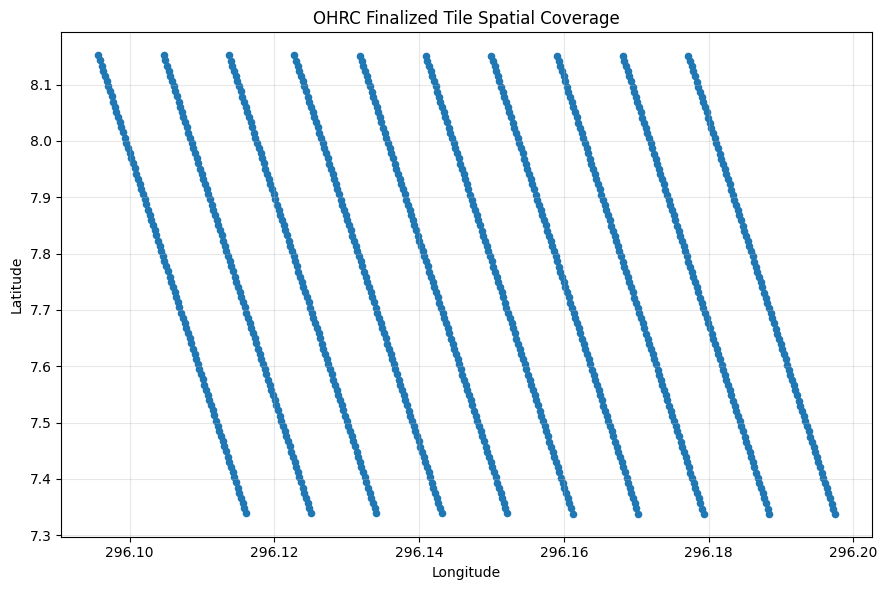

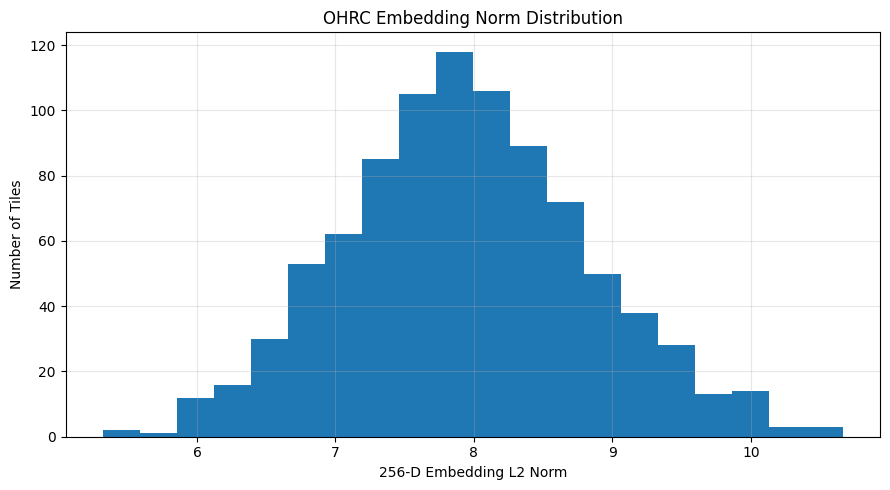


[OK] OHRC spatial metadata is finite.
[OK] OHRC embeddings are finite.
[OK] No complete embedding collapse detected.


In [27]:
# =============================================================================
# CELL 11 — OHRC EMBEDDING + SPATIAL SANITY CHECK
# =============================================================================

print("=" * 80)
print("OHRC SPATIAL + EMBEDDING SANITY CHECK")
print("=" * 80)

lat = OHRC_EMBEDDING_DF[
    "lat"
].to_numpy(
    dtype=np.float64
)

lon = OHRC_EMBEDDING_DF[
    "lon"
].to_numpy(
    dtype=np.float64
)

embedding_norms = np.linalg.norm(
    OHRC_EMBEDDINGS,
    axis=1
)


# -------------------------------------------------------------------------
# Spatial coverage
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("SPATIAL COVERAGE")
print("-" * 80)

print(
    f"Latitude range  : "
    f"{lat.min():.6f} → {lat.max():.6f}"
)

print(
    f"Longitude range : "
    f"{lon.min():.6f} → {lon.max():.6f}"
)

print(
    f"Latitude span   : "
    f"{lat.max() - lat.min():.6f}"
)

print(
    f"Longitude span  : "
    f"{lon.max() - lon.min():.6f}"
)

duplicate_coordinates = (
    OHRC_EMBEDDING_DF[
        ["lat", "lon"]
    ]
    .round(8)
    .duplicated()
    .sum()
)

print(
    f"Duplicate lat/lon rows: "
    f"{duplicate_coordinates}"
)


# -------------------------------------------------------------------------
# Embedding norms
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("EMBEDDING NORMS")
print("-" * 80)

print(
    f"Minimum norm : "
    f"{embedding_norms.min():.6f}"
)

print(
    f"Maximum norm : "
    f"{embedding_norms.max():.6f}"
)

print(
    f"Mean norm    : "
    f"{embedding_norms.mean():.6f}"
)

print(
    f"Std norm     : "
    f"{embedding_norms.std():.6f}"
)


# -------------------------------------------------------------------------
# Collapse check
# -------------------------------------------------------------------------

dimension_std = OHRC_EMBEDDINGS.std(
    axis=0
)

near_constant_dimensions = (
    dimension_std < 1e-6
).sum()

print(
    f"\nNear-constant dimensions "
    f"(std < 1e-6): "
    f"{near_constant_dimensions}/{EMBED_DIM}"
)


# -------------------------------------------------------------------------
# Pairwise cosine similarity
# -------------------------------------------------------------------------

normalized_embeddings = (
    OHRC_EMBEDDINGS
    / np.clip(
        embedding_norms[:, None],
        1e-12,
        None
    )
)

cosine_matrix = (
    normalized_embeddings
    @ normalized_embeddings.T
)

off_diagonal = cosine_matrix[
    ~np.eye(
        len(cosine_matrix),
        dtype=bool
    )
]

print("\n" + "-" * 80)
print("PAIRWISE COSINE SIMILARITY")
print("-" * 80)

print(
    f"Minimum : "
    f"{off_diagonal.min():.6f}"
)

print(
    f"Maximum : "
    f"{off_diagonal.max():.6f}"
)

print(
    f"Mean    : "
    f"{off_diagonal.mean():.6f}"
)

print(
    f"Std     : "
    f"{off_diagonal.std():.6f}"
)


# -------------------------------------------------------------------------
# Spatial plot
# -------------------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    lon,
    lat,
    s=20
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "OHRC Finalized Tile Spatial Coverage"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Embedding norm distribution
# -------------------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    embedding_norms,
    bins=20
)

plt.xlabel(
    "256-D Embedding L2 Norm"
)

plt.ylabel(
    "Number of Tiles"
)

plt.title(
    "OHRC Embedding Norm Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Final validation
# -------------------------------------------------------------------------

assert np.isfinite(lat).all()
assert np.isfinite(lon).all()
assert np.isfinite(OHRC_EMBEDDINGS).all()

assert near_constant_dimensions < EMBED_DIM

print(
    "\n[OK] OHRC spatial metadata is finite."
)

print(
    "[OK] OHRC embeddings are finite."
)

print(
    "[OK] No complete embedding collapse detected."
)

FINAL OHRC EMBEDDING-SPACE PCA DIAGNOSTIC

--------------------------------------------------------------------------------
PCA EXPLAINED VARIANCE
--------------------------------------------------------------------------------
PC1 variance explained : 24.25%
PC2 variance explained : 14.64%
PC1 + PC2              : 38.89%


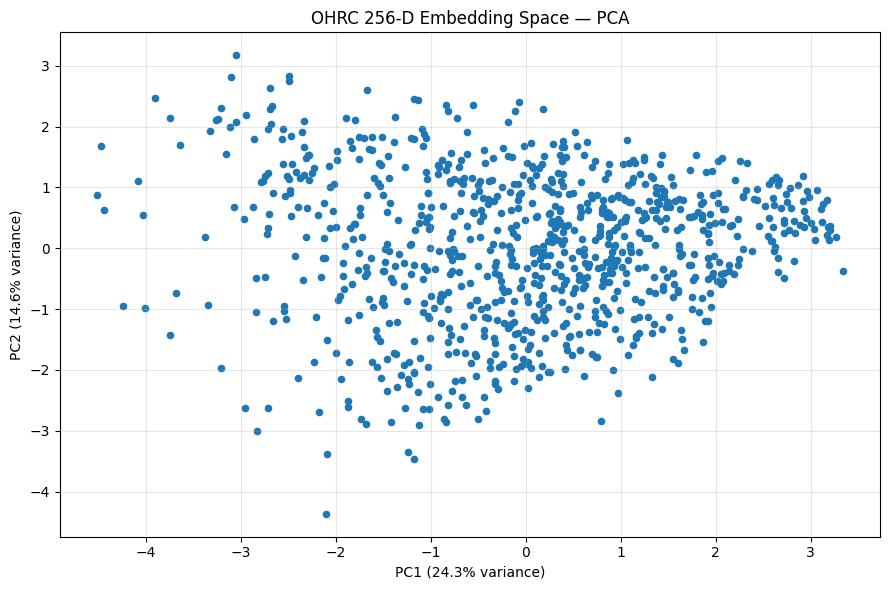

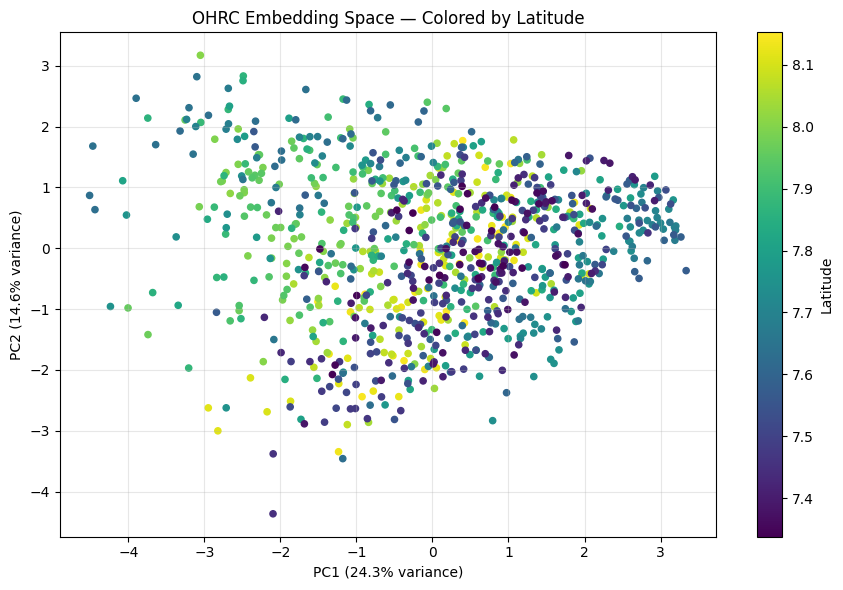


--------------------------------------------------------------------------------
PCA VERIFICATION
--------------------------------------------------------------------------------
PCA matrix shape : (900, 2)
Finite values    : True
Saved diagnostic : D:\ISRO\OHRC_TMC2_correspondence\ohrc_embedding_pca.csv

[OK] OHRC embedding-space PCA diagnostic complete.


In [30]:
# =============================================================================
# CELL 12 — FINAL OHRC EMBEDDING-SPACE PCA DIAGNOSTIC
# =============================================================================

SEED = 42
print("=" * 80)
print("FINAL OHRC EMBEDDING-SPACE PCA DIAGNOSTIC")
print("=" * 80)

from sklearn.decomposition import PCA


# -------------------------------------------------------------------------
# Ensure output directory exists
# -------------------------------------------------------------------------

OHRC_CORRESPONDENCE_ROOT = (
    Path(r"D:\ISRO") /
    "OHRC_TMC2_correspondence"
)

OHRC_CORRESPONDENCE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------------------------------------------------------
# PCA
# -------------------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=SEED
)

OHRC_PCA = pca.fit_transform(
    OHRC_EMBEDDINGS
)


pc1_variance = (
    pca.explained_variance_ratio_[0]
)

pc2_variance = (
    pca.explained_variance_ratio_[1]
)

total_variance = (
    pc1_variance +
    pc2_variance
)


print("\n" + "-" * 80)
print("PCA EXPLAINED VARIANCE")
print("-" * 80)

print(
    f"PC1 variance explained : "
    f"{pc1_variance * 100:.2f}%"
)

print(
    f"PC2 variance explained : "
    f"{pc2_variance * 100:.2f}%"
)

print(
    f"PC1 + PC2              : "
    f"{total_variance * 100:.2f}%"
)


# -------------------------------------------------------------------------
# Create PCA dataframe
# -------------------------------------------------------------------------

OHRC_PCA_DF = (
    OHRC_EMBEDDING_DF
    .copy()
)

OHRC_PCA_DF["PC1"] = OHRC_PCA[:, 0]
OHRC_PCA_DF["PC2"] = OHRC_PCA[:, 1]


# -------------------------------------------------------------------------
# PCA plot
# -------------------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    OHRC_PCA[:, 0],
    OHRC_PCA[:, 1],
    s=20
)

plt.xlabel(
    f"PC1 ({pc1_variance * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pc2_variance * 100:.1f}% variance)"
)

plt.title(
    "OHRC 256-D Embedding Space — PCA"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# PCA colored by latitude
# -------------------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

scatter = plt.scatter(
    OHRC_PCA[:, 0],
    OHRC_PCA[:, 1],
    c=OHRC_PCA_DF["lat"].to_numpy(),
    s=20
)

plt.xlabel(
    f"PC1 ({pc1_variance * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pc2_variance * 100:.1f}% variance)"
)

plt.title(
    "OHRC Embedding Space — Colored by Latitude"
)

plt.colorbar(
    scatter,
    label="Latitude"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Save PCA diagnostic
# -------------------------------------------------------------------------

OHRC_PCA_PATH = (
    OHRC_CORRESPONDENCE_ROOT /
    "ohrc_embedding_pca.csv"
)

OHRC_PCA_DF.to_csv(
    OHRC_PCA_PATH,
    index=False
)


# -------------------------------------------------------------------------
# Validation
# -------------------------------------------------------------------------

assert OHRC_PCA.shape == (
    900,
    2
)

assert np.isfinite(
    OHRC_PCA
).all()

assert len(
    OHRC_PCA_DF
) == 900


print("\n" + "-" * 80)
print("PCA VERIFICATION")
print("-" * 80)

print(
    f"PCA matrix shape : "
    f"{OHRC_PCA.shape}"
)

print(
    f"Finite values    : "
    f"{np.isfinite(OHRC_PCA).all()}"
)

print(
    f"Saved diagnostic : "
    f"{OHRC_PCA_PATH}"
)

print(
    "\n[OK] OHRC embedding-space PCA diagnostic complete."
)

In [31]:
# =============================================================================
# CELL 13 — SAVE FINAL OHRC CORRESPONDENCE ARTIFACTS
# =============================================================================

print("=" * 80)
print("SAVING FINAL OHRC CORRESPONDENCE ARTIFACTS")
print("=" * 80)

# -------------------------------------------------------------------------
# Output directory
# -------------------------------------------------------------------------

OHRC_CORRESPONDENCE_ROOT = (
    Path(r"D:\ISRO") /
    "OHRC_TMC2_correspondence"
)

OHRC_CORRESPONDENCE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------------------------------------------------------
# Output paths
# -------------------------------------------------------------------------

OHRC_EMBEDDINGS_PATH = (
    OHRC_CORRESPONDENCE_ROOT /
    "ohrc_embeddings_256.npy"
)

OHRC_METADATA_PATH = (
    OHRC_CORRESPONDENCE_ROOT /
    "ohrc_embeddings_metadata.csv"
)

OHRC_ARTIFACT_PATH = (
    OHRC_CORRESPONDENCE_ROOT /
    "ohrc_correspondence_artifact.npz"
)

OHRC_TABLE_PATH = (
    OHRC_CORRESPONDENCE_ROOT /
    "ohrc_correspondence_table.csv"
)


# -------------------------------------------------------------------------
# Add stable OHRC index if not already present
# -------------------------------------------------------------------------

if "ohrc_index" not in OHRC_EMBEDDING_DF.columns:

    OHRC_EMBEDDING_DF.insert(
        0,
        "ohrc_index",
        np.arange(
            len(OHRC_EMBEDDINGS),
            dtype=np.int64
        )
    )


# -------------------------------------------------------------------------
# Save embedding matrix
# -------------------------------------------------------------------------

np.save(
    OHRC_EMBEDDINGS_PATH,
    OHRC_EMBEDDINGS
)


# -------------------------------------------------------------------------
# Save metadata/table
# -------------------------------------------------------------------------

OHRC_EMBEDDING_DF.to_csv(
    OHRC_METADATA_PATH,
    index=False
)

OHRC_EMBEDDING_DF.to_csv(
    OHRC_TABLE_PATH,
    index=False
)


# -------------------------------------------------------------------------
# Save combined artifact
# -------------------------------------------------------------------------

np.savez_compressed(
    OHRC_ARTIFACT_PATH,
    embeddings=OHRC_EMBEDDINGS,
    manifest_indices=np.asarray(
        ohrc_valid_rows,
        dtype=np.int64
    )
)


# -------------------------------------------------------------------------
# Reload everything
# -------------------------------------------------------------------------

reloaded_embeddings = np.load(
    OHRC_EMBEDDINGS_PATH,
    allow_pickle=False
)

reloaded_metadata = pd.read_csv(
    OHRC_METADATA_PATH
)

with np.load(
    OHRC_ARTIFACT_PATH,
    allow_pickle=False
) as artifact:

    artifact_embeddings = (
        artifact["embeddings"]
    )

    artifact_indices = (
        artifact["manifest_indices"]
    )


# -------------------------------------------------------------------------
# Hard validation
# -------------------------------------------------------------------------

assert reloaded_embeddings.shape == (
    900,
    EMBED_DIM
)

assert artifact_embeddings.shape == (
    900,
    EMBED_DIM
)

assert len(reloaded_metadata) == 900

assert np.array_equal(
    reloaded_embeddings,
    OHRC_EMBEDDINGS
)

assert np.array_equal(
    artifact_embeddings,
    OHRC_EMBEDDINGS
)

assert len(artifact_indices) == 900

assert reloaded_metadata[
    "lat"
].notna().all()

assert reloaded_metadata[
    "lon"
].notna().all()


# -------------------------------------------------------------------------
# Final report
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FINAL OHRC ARTIFACT VERIFICATION")
print("-" * 80)

print(
    f"Embedding matrix : "
    f"{reloaded_embeddings.shape}"
)

print(
    f"Metadata rows     : "
    f"{len(reloaded_metadata)}"
)

print(
    f"Latitude valid    : "
    f"{reloaded_metadata['lat'].notna().sum()}/900"
)

print(
    f"Longitude valid   : "
    f"{reloaded_metadata['lon'].notna().sum()}/900"
)

print(
    f"Finite embeddings : "
    f"{np.isfinite(reloaded_embeddings).all()}"
)


print("\nSaved artifacts:")

for path in [
    OHRC_EMBEDDINGS_PATH,
    OHRC_METADATA_PATH,
    OHRC_ARTIFACT_PATH,
    OHRC_TABLE_PATH,
    OHRC_PCA_PATH,
]:

    print(
        f"  {path}"
    )

    print(
        f"    Exists: {path.exists()}"
    )


print("\n" + "=" * 80)
print("🔒 OHRC SIDE COMPLETE AND READY FOR TMC-2")
print("=" * 80)

SAVING FINAL OHRC CORRESPONDENCE ARTIFACTS

--------------------------------------------------------------------------------
FINAL OHRC ARTIFACT VERIFICATION
--------------------------------------------------------------------------------
Embedding matrix : (900, 256)
Metadata rows     : 900
Latitude valid    : 900/900
Longitude valid   : 900/900
Finite embeddings : True

Saved artifacts:
  D:\ISRO\OHRC_TMC2_correspondence\ohrc_embeddings_256.npy
    Exists: True
  D:\ISRO\OHRC_TMC2_correspondence\ohrc_embeddings_metadata.csv
    Exists: True
  D:\ISRO\OHRC_TMC2_correspondence\ohrc_correspondence_artifact.npz
    Exists: True
  D:\ISRO\OHRC_TMC2_correspondence\ohrc_correspondence_table.csv
    Exists: True
  D:\ISRO\OHRC_TMC2_correspondence\ohrc_embedding_pca.csv
    Exists: True

🔒 OHRC SIDE COMPLETE AND READY FOR TMC-2


In [44]:
# =============================================================================
# CELL 18 — OHRC ↔ TMC-2 CAMERA-WISE GEOGRAPHIC OVERLAP ANALYSIS
# =============================================================================
#
# PURPOSE
# -------
# Check whether the CURRENT finalized OHRC observation has geographic
# correspondence with the CURRENT finalized TMC-2 data.
#
# CAMERA POLICY
# -------------
#   AFT only              -> test AFT
#   NADIR only            -> test NADIR
#   FORE only             -> test FORE
#   AFT + NADIR           -> test both
#   AFT + FORE            -> test both
#   NADIR + FORE          -> test both
#   AFT + NADIR + FORE    -> test all three
#
# No camera is required.
# No missing camera is fabricated.
# No preprocessing is performed.
# No encoder is retrained.
# No correspondence mapper is trained.
#
# This cell performs a GEOGRAPHIC FEASIBILITY TEST only.
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path


print("=" * 80)
print("OHRC ↔ TMC-2 CAMERA-WISE GEOGRAPHIC OVERLAP ANALYSIS")
print("=" * 80)


# =============================================================================
# 1. PROJECT / OUTPUT PATHS
# =============================================================================

PROJECT_ROOT_LOCAL = Path(r"D:\ISRO")

OHRC_DIR = (
    PROJECT_ROOT_LOCAL /
    "OHRC_tiles"
)

TMC2_DIR = (
    PROJECT_ROOT_LOCAL /
    "TMC_tiles"
)

OHRC_TMC2_OUT_ROOT = (
    PROJECT_ROOT_LOCAL /
    "OHRC_TMC2_correspondence"
)

OHRC_TMC2_PAIRS_DIR = (
    OHRC_TMC2_OUT_ROOT /
    "pairs"
)

OHRC_TMC2_EVAL_DIR = (
    OHRC_TMC2_OUT_ROOT /
    "evaluation"
)

OHRC_TMC2_PAIRS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OHRC_TMC2_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. LOAD FINALIZED OHRC MANIFEST
# =============================================================================

print("\n" + "-" * 80)
print("LOADING OHRC MANIFEST")
print("-" * 80)


OHRC_MANIFEST_PATH = (
    OHRC_DIR /
    "ohrc_manifest.csv"
)


if not OHRC_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"OHRC manifest not found:\n"
        f"{OHRC_MANIFEST_PATH}"
    )


OHRC_META = pd.read_csv(
    OHRC_MANIFEST_PATH
)


print(
    f"OHRC manifest: {OHRC_MANIFEST_PATH}"
)

print(
    f"OHRC rows: {len(OHRC_META)}"
)


# =============================================================================
# 3. VALIDATE OHRC COORDINATES
# =============================================================================

required_ohrc_columns = [
    "lat",
    "lon",
]


missing_ohrc_columns = [
    column
    for column in required_ohrc_columns
    if column not in OHRC_META.columns
]


if missing_ohrc_columns:

    raise KeyError(
        "OHRC manifest is missing required columns: "
        + ", ".join(missing_ohrc_columns)
        + "\n\nAvailable columns:\n"
        + str(list(OHRC_META.columns))
    )


ohrc_lat_all = pd.to_numeric(
    OHRC_META["lat"],
    errors="coerce"
).to_numpy(
    dtype=np.float64
)


ohrc_lon_all = pd.to_numeric(
    OHRC_META["lon"],
    errors="coerce"
).to_numpy(
    dtype=np.float64
)


ohrc_valid = (
    np.isfinite(ohrc_lat_all)
    &
    np.isfinite(ohrc_lon_all)
)


ohrc_indices = np.where(
    ohrc_valid
)[0]


ohrc_lat = ohrc_lat_all[
    ohrc_valid
]


ohrc_lon = ohrc_lon_all[
    ohrc_valid
]


if len(ohrc_lat) == 0:

    raise RuntimeError(
        "No valid OHRC geographic coordinates found."
    )


# =============================================================================
# 4. NORMALIZE LONGITUDE
# =============================================================================

def normalize_longitude(lon):
    """
    Normalize longitude to [-180, 180).
    """

    return (
        (
            np.asarray(
                lon,
                dtype=np.float64
            )
            + 180.0
        )
        % 360.0
    ) - 180.0


ohrc_lon_normalized = normalize_longitude(
    ohrc_lon
)


# =============================================================================
# 5. LOAD FINALIZED TMC-2 EMBEDDING MANIFEST
# =============================================================================

print("\n" + "-" * 80)
print("LOADING TMC-2 EMBEDDING METADATA")
print("-" * 80)


TMC2_MANIFEST_PATH = (
    TMC2_DIR /
    "mvp_embeddings_manifest.csv"
)


if not TMC2_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"TMC-2 embedding manifest not found:\n"
        f"{TMC2_MANIFEST_PATH}"
    )


TMC2_META = pd.read_csv(
    TMC2_MANIFEST_PATH
)


print(
    f"TMC-2 manifest: {TMC2_MANIFEST_PATH}"
)

print(
    f"TMC-2 rows: {len(TMC2_META)}"
)


# =============================================================================
# 6. VALIDATE TMC-2 METADATA
# =============================================================================

required_tmc_columns = [
    "camera",
    "lat",
    "lon",
]


missing_tmc_columns = [
    column
    for column in required_tmc_columns
    if column not in TMC2_META.columns
]


if missing_tmc_columns:

    raise KeyError(
        "TMC-2 manifest is missing required columns: "
        + ", ".join(missing_tmc_columns)
        + "\n\nAvailable columns:\n"
        + str(list(TMC2_META.columns))
    )


TMC2_META["_lat_numeric"] = pd.to_numeric(
    TMC2_META["lat"],
    errors="coerce"
)


TMC2_META["_lon_numeric"] = pd.to_numeric(
    TMC2_META["lon"],
    errors="coerce"
)


TMC2_META["_lon_normalized"] = normalize_longitude(
    TMC2_META["_lon_numeric"].to_numpy(
        dtype=np.float64
    )
)


TMC2_META["_coord_valid"] = (
    np.isfinite(
        TMC2_META["_lat_numeric"].to_numpy(
            dtype=np.float64
        )
    )
    &
    np.isfinite(
        TMC2_META["_lon_normalized"].to_numpy(
            dtype=np.float64
        )
    )
)


TMC2_META["_camera_normalized"] = (
    TMC2_META["camera"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# =============================================================================
# 7. AVAILABLE CAMERA DISCOVERY
# =============================================================================

CAMERA_ORDER = [
    "AFT",
    "NADIR",
    "FORE",
]


available_cameras = [
    camera
    for camera in CAMERA_ORDER
    if (
        TMC2_META["_camera_normalized"].eq(camera)
        &
        TMC2_META["_coord_valid"]
    ).any()
]


print("\n" + "-" * 80)
print("AVAILABLE TMC-2 CAMERAS")
print("-" * 80)


for camera in CAMERA_ORDER:

    count = int(
        (
            TMC2_META["_camera_normalized"].eq(camera)
            &
            TMC2_META["_coord_valid"]
        ).sum()
    )

    if count > 0:

        print(
            f"{camera:5s}: {count} geolocated patches"
        )

    else:

        print(
            f"{camera:5s}: not available"
        )


if len(available_cameras) == 0:

    raise RuntimeError(
        "No geolocated TMC-2 AFT/NADIR/FORE patches are available."
    )


print(
    f"\n[OK] Cameras to evaluate: "
    f"{available_cameras}"
)


# =============================================================================
# 8. MOON HAVERSINE DISTANCE
# =============================================================================

MOON_RADIUS_M = 1_737_400.0


def haversine_matrix_m(
    lat1_deg,
    lon1_deg,
    lat2_deg,
    lon2_deg,
):
    """
    Pairwise great-circle distance on the Moon in metres.
    """

    lat1 = np.radians(
        np.asarray(
            lat1_deg,
            dtype=np.float64
        )
    )[:, None]


    lon1 = np.radians(
        np.asarray(
            lon1_deg,
            dtype=np.float64
        )
    )[:, None]


    lat2 = np.radians(
        np.asarray(
            lat2_deg,
            dtype=np.float64
        )
    )[None, :]


    lon2 = np.radians(
        np.asarray(
            lon2_deg,
            dtype=np.float64
        )
    )[None, :]


    dlat = lat2 - lat1
    dlon = lon2 - lon1


    a = (
        np.sin(dlat / 2.0) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon / 2.0) ** 2
    )


    a = np.clip(
        a,
        0.0,
        1.0
    )


    c = (
        2.0
        *
        np.arcsin(
            np.sqrt(a)
        )
    )


    return (
        MOON_RADIUS_M
        *
        c
    )


# =============================================================================
# 9. CAMERA-WISE OVERLAP ANALYSIS
# =============================================================================

OHRC_TMC2_OVERLAP_RESULTS = []

OHRC_TMC2_CANDIDATE_PAIRS = {}


for camera in available_cameras:

    print("\n")
    print("=" * 80)
    print(f"TMC-2 CAMERA: {camera}")
    print("=" * 80)


    # -------------------------------------------------------------------------
    # Select this camera only
    # -------------------------------------------------------------------------

    camera_mask = (
        TMC2_META["_camera_normalized"].eq(camera)
        &
        TMC2_META["_coord_valid"]
    )


    camera_meta = (
        TMC2_META[
            camera_mask
        ]
        .copy()
        .reset_index(drop=False)
        .rename(
            columns={
                "index": "_original_tmc_index"
            }
        )
    )


    tmc_lat = camera_meta[
        "_lat_numeric"
    ].to_numpy(
        dtype=np.float64
    )


    tmc_lon = camera_meta[
        "_lon_normalized"
    ].to_numpy(
        dtype=np.float64
    )


    # -------------------------------------------------------------------------
    # Geographic coverage
    # -------------------------------------------------------------------------

    ohrc_lat_min = float(
        ohrc_lat.min()
    )

    ohrc_lat_max = float(
        ohrc_lat.max()
    )

    ohrc_lon_min = float(
        ohrc_lon_normalized.min()
    )

    ohrc_lon_max = float(
        ohrc_lon_normalized.max()
    )


    tmc_lat_min = float(
        tmc_lat.min()
    )

    tmc_lat_max = float(
        tmc_lat.max()
    )

    tmc_lon_min = float(
        tmc_lon.min()
    )

    tmc_lon_max = float(
        tmc_lon.max()
    )


    latitude_overlap_min = max(
        ohrc_lat_min,
        tmc_lat_min
    )


    latitude_overlap_max = min(
        ohrc_lat_max,
        tmc_lat_max
    )


    longitude_overlap_min = max(
        ohrc_lon_min,
        tmc_lon_min
    )


    longitude_overlap_max = min(
        ohrc_lon_max,
        tmc_lon_max
    )


    latitude_overlap = (
        latitude_overlap_min
        <=
        latitude_overlap_max
    )


    longitude_overlap = (
        longitude_overlap_min
        <=
        longitude_overlap_max
    )


    bbox_overlap = (
        latitude_overlap
        and
        longitude_overlap
    )


    print("\n" + "-" * 80)
    print("GEOGRAPHIC COVERAGE")
    print("-" * 80)


    print(
        f"OHRC latitude range       : "
        f"{ohrc_lat_min:.6f} → {ohrc_lat_max:.6f}"
    )


    print(
        f"OHRC longitude range      : "
        f"{ohrc_lon_min:.6f} → {ohrc_lon_max:.6f}"
    )


    print(
        f"{camera} latitude range     : "
        f"{tmc_lat_min:.6f} → {tmc_lat_max:.6f}"
    )


    print(
        f"{camera} longitude range    : "
        f"{tmc_lon_min:.6f} → {tmc_lon_max:.6f}"
    )


    print(
        f"\nLatitude bbox overlap     : "
        f"{'YES' if latitude_overlap else 'NO'}"
    )


    print(
        f"Longitude bbox overlap    : "
        f"{'YES' if longitude_overlap else 'NO'}"
    )


    print(
        f"Overall bbox overlap      : "
        f"{'YES' if bbox_overlap else 'NO'}"
    )


    # -------------------------------------------------------------------------
    # Nearest TMC-2 patch for every OHRC patch
    # -------------------------------------------------------------------------

    distance_matrix = haversine_matrix_m(
        ohrc_lat,
        ohrc_lon_normalized,
        tmc_lat,
        tmc_lon,
    )


    nearest_tmc_positions = np.argmin(
        distance_matrix,
        axis=1
    )


    nearest_distances_m = np.min(
        distance_matrix,
        axis=1
    )


    print("\n" + "-" * 80)
    print("NEAREST-PATCH DISTANCES")
    print("-" * 80)


    print(
        f"Minimum OHRC → {camera} distance : "
        f"{nearest_distances_m.min():,.2f} m"
    )


    print(
        f"Maximum nearest distance          : "
        f"{nearest_distances_m.max():,.2f} m"
    )


    print(
        f"Mean nearest distance             : "
        f"{nearest_distances_m.mean():,.2f} m"
    )


    print(
        f"Median nearest distance           : "
        f"{np.median(nearest_distances_m):,.2f} m"
    )


    # -------------------------------------------------------------------------
    # 300 m correspondence threshold
    # -------------------------------------------------------------------------

    candidate_mask = (
        nearest_distances_m
        <=
        MAX_PAIR_DISTANCE_M
    )


    candidate_count = int(
        candidate_mask.sum()
    )


    print("\n" + "-" * 80)
    print("CORRESPONDENCE TEST")
    print("-" * 80)


    print(
        f"Maximum allowed distance : "
        f"{MAX_PAIR_DISTANCE_M:.1f} m"
    )


    print(
        f"OHRC tiles within threshold: "
        f"{candidate_count}/{len(ohrc_lat)}"
    )


    # -------------------------------------------------------------------------
    # Build candidate pairs
    # -------------------------------------------------------------------------

    candidate_rows = []


    for local_ohrc_position in np.where(
        candidate_mask
    )[0]:

        local_tmc_position = int(
            nearest_tmc_positions[
                local_ohrc_position
            ]
        )


        original_ohrc_index = int(
            ohrc_indices[
                local_ohrc_position
            ]
        )


        original_tmc_index = int(
            camera_meta.loc[
                local_tmc_position,
                "_original_tmc_index"
            ]
        )


        distance_m = float(
            nearest_distances_m[
                local_ohrc_position
            ]
        )


        row = {
            "ohrc_index": original_ohrc_index,
            "tmc2_index": original_tmc_index,
            "camera": camera,
            "distance_m": distance_m,
            "ohrc_lat": float(
                ohrc_lat[
                    local_ohrc_position
                ]
            ),
            "ohrc_lon": float(
                ohrc_lon[
                    local_ohrc_position
                ]
            ),
            "tmc2_lat": float(
                tmc_lat[
                    local_tmc_position
                ]
            ),
            "tmc2_lon": float(
                tmc_lon[
                    local_tmc_position
                ]
            ),
        }


        # Preserve TMC-2 identifiers.
        for column in [
            "patch_id",
            "source_scene_id",
            "source_product_id",
            "observation_id",
        ]:

            if column in camera_meta.columns:

                row[
                    f"tmc2_{column}"
                ] = camera_meta.loc[
                    local_tmc_position,
                    column
                ]


        # Preserve OHRC identifiers.
        for column in [
            "source_scene_id",
            "tile_row",
            "tile_col",
        ]:

            if column in OHRC_META.columns:

                row[
                    f"ohrc_{column}"
                ] = OHRC_META.loc[
                    original_ohrc_index,
                    column
                ]


        candidate_rows.append(
            row
        )


    camera_pairs_df = pd.DataFrame(
        candidate_rows
    )


    OHRC_TMC2_CANDIDATE_PAIRS[
        camera
    ] = camera_pairs_df


    # -------------------------------------------------------------------------
    # Closest pair
    # -------------------------------------------------------------------------

    closest_position = int(
        np.argmin(
            nearest_distances_m
        )
    )


    closest_tmc_position = int(
        nearest_tmc_positions[
            closest_position
        ]
    )


    closest_ohrc_index = int(
        ohrc_indices[
            closest_position
        ]
    )


    closest_tmc_index = int(
        camera_meta.loc[
            closest_tmc_position,
            "_original_tmc_index"
        ]
    )


    closest_distance = float(
        nearest_distances_m[
            closest_position
        ]
    )


    print("\n" + "-" * 80)
    print(f"CLOSEST OHRC ↔ {camera} PAIR")
    print("-" * 80)


    print(
        f"OHRC index       : "
        f"{closest_ohrc_index}"
    )


    print(
        f"OHRC coordinates : "
        f"({ohrc_lat[closest_position]:.6f}, "
        f"{ohrc_lon[closest_position]:.6f}°)"
    )


    print(
        f"TMC-2 index      : "
        f"{closest_tmc_index}"
    )


    print(
        f"TMC-2 coordinates: "
        f"({tmc_lat[closest_tmc_position]:.6f}, "
        f"{tmc_lon[closest_tmc_position]:.6f}°)"
    )


    print(
        f"Distance         : "
        f"{closest_distance:,.2f} m"
    )


    # -------------------------------------------------------------------------
    # Save camera result in memory
    # -------------------------------------------------------------------------

    OHRC_TMC2_OVERLAP_RESULTS.append(
        {
            "camera": camera,
            "tmc2_patches": len(camera_meta),
            "bbox_overlap": bbox_overlap,
            "nearest_min_m": float(
                nearest_distances_m.min()
            ),
            "nearest_mean_m": float(
                nearest_distances_m.mean()
            ),
            "nearest_median_m": float(
                np.median(nearest_distances_m)
            ),
            "candidate_ohrc": candidate_count,
        }
    )


# =============================================================================
# 10. ALL-CAMERA SUMMARY
# =============================================================================

OHRC_TMC2_OVERLAP_SUMMARY = pd.DataFrame(
    OHRC_TMC2_OVERLAP_RESULTS
)


print("\n\n" + "=" * 80)
print("ALL-CAMERA OHRC ↔ TMC-2 OVERLAP SUMMARY")
print("=" * 80)


if len(
    OHRC_TMC2_OVERLAP_SUMMARY
) > 0:

    display(
        OHRC_TMC2_OVERLAP_SUMMARY
    )

else:

    print(
        "[WARNING] No camera overlap results generated."
    )


# =============================================================================
# 11. COMBINE CANDIDATE PAIRS
# =============================================================================

non_empty_pair_tables = [
    df
    for df in OHRC_TMC2_CANDIDATE_PAIRS.values()
    if len(df) > 0
]


if len(non_empty_pair_tables) > 0:

    ALL_OHRC_TMC2_CANDIDATE_PAIRS = pd.concat(
        non_empty_pair_tables,
        ignore_index=True
    )

else:

    ALL_OHRC_TMC2_CANDIDATE_PAIRS = pd.DataFrame()


print("\n" + "-" * 80)
print("COMBINED CAMERA CANDIDATES")
print("-" * 80)


print(
    f"Total candidate pairs across all available cameras: "
    f"{len(ALL_OHRC_TMC2_CANDIDATE_PAIRS)}"
)


if len(
    ALL_OHRC_TMC2_CANDIDATE_PAIRS
) > 0:

    print(
        "\nCandidate pairs by camera:"
    )

    print(
        ALL_OHRC_TMC2_CANDIDATE_PAIRS[
            "camera"
        ]
        .value_counts()
        .to_string()
    )

    display(
        ALL_OHRC_TMC2_CANDIDATE_PAIRS.head(
            20
        )
    )


# =============================================================================
# 12. SAVE RESULTS
# =============================================================================

overlap_summary_path = (
    OHRC_TMC2_EVAL_DIR /
    "camera_overlap_summary.csv"
)


OHRC_TMC2_OVERLAP_SUMMARY.to_csv(
    overlap_summary_path,
    index=False
)


candidate_pairs_path = (
    OHRC_TMC2_PAIRS_DIR /
    "camera_geographic_candidate_pairs.csv"
)


ALL_OHRC_TMC2_CANDIDATE_PAIRS.to_csv(
    candidate_pairs_path,
    index=False
)


print("\n" + "-" * 80)
print("SAVED DIAGNOSTICS")
print("-" * 80)


print(
    f"Overlap summary:\n"
    f"  {overlap_summary_path}"
)


print(
    f"\nCandidate pairs:\n"
    f"  {candidate_pairs_path}"
)


# =============================================================================
# 13. FINAL DECISION
# =============================================================================

print("\n" + "=" * 80)
print("OHRC ↔ TMC-2 GEOGRAPHIC CORRESPONDENCE DECISION")
print("=" * 80)


if len(
    ALL_OHRC_TMC2_CANDIDATE_PAIRS
) == 0:

    print(
        f"\n[STOP] No OHRC ↔ TMC-2 candidate pairs exist "
        f"within {MAX_PAIR_DISTANCE_M:.1f} m."
    )

    print(
        "[IMPORTANT] Do NOT train the OHRC ↔ TMC-2 "
        "correspondence mapper on these observations."
    )

    print(
        "[ACTION] A geographically overlapping TMC-2 "
        "observation is required."
    )

else:

    print(
        f"\n[READY] "
        f"{len(ALL_OHRC_TMC2_CANDIDATE_PAIRS)} "
        f"candidate pair(s) found."
    )

    print(
        "\n[OK] Every available TMC-2 camera with valid "
        "candidates has been retained."
    )

    print(
        "[OK] AFT/NADIR/FORE completeness is NOT required."
    )

    print(
        "\nCandidate counts by camera:"
    )

    print(
        ALL_OHRC_TMC2_CANDIDATE_PAIRS[
            "camera"
        ]
        .value_counts()
        .to_string()
    )


print("\n" + "=" * 80)
print("OHRC ↔ TMC-2 CAMERA-WISE ANALYSIS COMPLETE")
print("=" * 80)

OHRC ↔ TMC-2 CAMERA-WISE GEOGRAPHIC OVERLAP ANALYSIS

--------------------------------------------------------------------------------
LOADING OHRC MANIFEST
--------------------------------------------------------------------------------
OHRC manifest: D:\ISRO\OHRC_tiles\ohrc_manifest.csv
OHRC rows: 900

--------------------------------------------------------------------------------
LOADING TMC-2 EMBEDDING METADATA
--------------------------------------------------------------------------------
TMC-2 manifest: D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
TMC-2 rows: 400

--------------------------------------------------------------------------------
AVAILABLE TMC-2 CAMERAS
--------------------------------------------------------------------------------
AFT  : 400 geolocated patches
NADIR: not available
FORE : not available

[OK] Cameras to evaluate: ['AFT']


TMC-2 CAMERA: AFT

--------------------------------------------------------------------------------
GEOGRAPHIC COVERAGE
-----

,camera,tmc2_patches,bbox_overlap,nearest_min_m,nearest_mean_m,nearest_median_m,candidate_ohrc
0,AFT,400,False,4.519985e+06,4.529693e+06,4.529704e+06,0



--------------------------------------------------------------------------------
COMBINED CAMERA CANDIDATES
--------------------------------------------------------------------------------
Total candidate pairs across all available cameras: 0

--------------------------------------------------------------------------------
SAVED DIAGNOSTICS
--------------------------------------------------------------------------------
Overlap summary:
  D:\ISRO\OHRC_TMC2_correspondence\evaluation\camera_overlap_summary.csv

Candidate pairs:
  D:\ISRO\OHRC_TMC2_correspondence\pairs\camera_geographic_candidate_pairs.csv

OHRC ↔ TMC-2 GEOGRAPHIC CORRESPONDENCE DECISION

[STOP] No OHRC ↔ TMC-2 candidate pairs exist within 300.0 m.
[IMPORTANT] Do NOT train the OHRC ↔ TMC-2 correspondence mapper on these observations.
[ACTION] A geographically overlapping TMC-2 observation is required.

OHRC ↔ TMC-2 CAMERA-WISE ANALYSIS COMPLETE


In [45]:
# =============================================================================
# CELL 1 — LOAD AND VALIDATE REAL OHRC + TMC-2 EMBEDDINGS
# =============================================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("OHRC ↔ TMC-2 CORRESPONDENCE MAPPER")
print("=" * 80)

# -------------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------------

PROJECT_ROOT = r"D:\ISRO"

OHRC_DIR = os.path.join(
    PROJECT_ROOT,
    "OHRC_tiles"
)

TMC2_DIR = os.path.join(
    PROJECT_ROOT,
    "TMC_tiles"
)

OUT_ROOT = os.path.join(
    PROJECT_ROOT,
    "OHRC_TMC2_correspondence"
)

PAIRS_DIR = os.path.join(
    OUT_ROOT,
    "pairs"
)

MODELS_DIR = os.path.join(
    OUT_ROOT,
    "models"
)

EVAL_DIR = os.path.join(
    OUT_ROOT,
    "evaluation"
)

PREDICTIONS_DIR = os.path.join(
    OUT_ROOT,
    "predictions"
)

for d in [
    OUT_ROOT,
    PAIRS_DIR,
    MODELS_DIR,
    EVAL_DIR,
    PREDICTIONS_DIR
]:
    os.makedirs(
        d,
        exist_ok=True
    )

# -------------------------------------------------------------------------
# Existing manifests
# -------------------------------------------------------------------------

OHRC_MANIFEST_PATH = os.path.join(
    OHRC_DIR,
    "ohrc_manifest.csv"
)

TMC2_MANIFEST_PATH = os.path.join(
    TMC2_DIR,
    "mvp_embeddings_manifest.csv"
)

# -------------------------------------------------------------------------
# OHRC embeddings
#
# The OHRC preprocessing/encoder pipeline produced 900 embeddings.
# If an embedding artifact already exists, use it.
# Otherwise this cell reports that it needs to be generated.
# -------------------------------------------------------------------------

OHRC_EMBEDDING_CANDIDATES = [
    os.path.join(
        OHRC_DIR,
        "ohrc_embeddings_256.npy"
    ),

    os.path.join(
        OUT_ROOT,
        "ohrc_embeddings_256.npy"
    ),

    os.path.join(
        OHRC_DIR,
        "embeddings_256.npy"
    )
]

OHRC_EMBEDDINGS_PATH = None

for candidate in OHRC_EMBEDDING_CANDIDATES:

    if os.path.exists(candidate):

        OHRC_EMBEDDINGS_PATH = candidate
        break

if OHRC_EMBEDDINGS_PATH is None:

    print()
    print("[WARNING] No saved OHRC 256-D embedding artifact found.")
    print()
    print("Expected one of:")

    for p in OHRC_EMBEDDING_CANDIDATES:
        print(f"  {p}")

    print()
    print(
        "We will generate the OHRC embeddings in the next cell "
        "using the FROZEN OHRC encoder if necessary."
    )

else:

    print(
        f"[OK] OHRC embeddings found: "
        f"{OHRC_EMBEDDINGS_PATH}"
    )

# -------------------------------------------------------------------------
# Load manifests
# -------------------------------------------------------------------------

OHRC_METADATA = pd.read_csv(
    OHRC_MANIFEST_PATH
)

TMC2_METADATA = pd.read_csv(
    TMC2_MANIFEST_PATH
)

print()
print("OHRC manifest:")
print(
    f"  Path: {OHRC_MANIFEST_PATH}"
)

print(
    f"  Rows: {len(OHRC_METADATA)}"
)

print()
print("TMC-2 manifest:")
print(
    f"  Path: {TMC2_MANIFEST_PATH}"
)

print(
    f"  Rows: {len(TMC2_METADATA)}"
)

# -------------------------------------------------------------------------
# Load OHRC embeddings if available
# -------------------------------------------------------------------------

if OHRC_EMBEDDINGS_PATH is not None:

    OHRC_EMBEDDINGS = np.load(
        OHRC_EMBEDDINGS_PATH
    ).astype(
        np.float32
    )

    print()
    print(
        f"OHRC embeddings shape: "
        f"{OHRC_EMBEDDINGS.shape}"
    )

    assert OHRC_EMBEDDINGS.ndim == 2
    assert OHRC_EMBEDDINGS.shape[1] == 256
    assert len(OHRC_EMBEDDINGS) == len(
        OHRC_METADATA
    )

    assert np.isfinite(
        OHRC_EMBEDDINGS
    ).all()

    print(
        "[OK] OHRC embeddings are valid 256-D finite vectors."
    )

# -------------------------------------------------------------------------
# Load TMC-2 embeddings
# -------------------------------------------------------------------------

TMC2_EMBEDDINGS_PATH = os.path.join(
    TMC2_DIR,
    "mvp_embeddings.npz"
)

TMC2_DATA = np.load(
    TMC2_EMBEDDINGS_PATH
)

TMC2_EMBEDDINGS = TMC2_DATA[
    "embeddings"
].astype(
    np.float32
)

print()
print(
    f"TMC-2 embeddings shape: "
    f"{TMC2_EMBEDDINGS.shape}"
)

assert TMC2_EMBEDDINGS.ndim == 2
assert TMC2_EMBEDDINGS.shape[1] == 256
assert len(TMC2_EMBEDDINGS) == len(
    TMC2_METADATA
)

assert np.isfinite(
    TMC2_EMBEDDINGS
).all()

print(
    "[OK] TMC-2 embeddings are valid 256-D finite vectors."
)

# -------------------------------------------------------------------------
# Final status
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("SOURCE DATA STATUS")
print("=" * 80)

print(
    "OHRC embeddings : "
    + (
        "AVAILABLE"
        if OHRC_EMBEDDINGS_PATH is not None
        else "NOT YET AVAILABLE"
    )
)

print(
    "TMC-2 embeddings: AVAILABLE"
)

print()
print(
    "Important: the previous geographic analysis found"
)

print(
    "NO real OHRC ↔ TMC-2 geographic correspondence"
)

print(
    "within the current observations."
)

print()
print(
    "Therefore we will NOT fabricate real geographic pairs."
)

print(
    "A controlled synthetic benchmark will be used to"
)

print(
    "validate the correspondence-learning mechanism."
)

print("=" * 80)
print("CELL 1 COMPLETE")
print("=" * 80)

OHRC ↔ TMC-2 CORRESPONDENCE MAPPER
[OK] OHRC embeddings found: D:\ISRO\OHRC_TMC2_correspondence\ohrc_embeddings_256.npy

OHRC manifest:
  Path: D:\ISRO\OHRC_tiles\ohrc_manifest.csv
  Rows: 900

TMC-2 manifest:
  Path: D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
  Rows: 400

OHRC embeddings shape: (900, 256)
[OK] OHRC embeddings are valid 256-D finite vectors.

TMC-2 embeddings shape: (400, 256)
[OK] TMC-2 embeddings are valid 256-D finite vectors.

SOURCE DATA STATUS
OHRC embeddings : AVAILABLE
TMC-2 embeddings: AVAILABLE

Important: the previous geographic analysis found
NO real OHRC ↔ TMC-2 geographic correspondence
within the current observations.

Therefore we will NOT fabricate real geographic pairs.
A controlled synthetic benchmark will be used to
validate the correspondence-learning mechanism.
CELL 1 COMPLETE


In [47]:
# =============================================================================
# CELL 2 — OHRC → TMC-2 CONTROLLED FIXED-TRANSFORM BENCHMARK
#              MILD / LEARNABLE VERSION
# =============================================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("OHRC → TMC-2 CONTROLLED CORRESPONDENCE BENCHMARK")
print("=" * 80)

# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------

SEED = 42

N_ANCHORS = len(TMC2_EMBEDDINGS)
VIEWS_PER_ANCHOR = 5
EMBED_DIM = 256

rng = np.random.default_rng(SEED)

print()
print("Real embedding sources:")
print(
    f"  OHRC embeddings : {OHRC_EMBEDDINGS.shape}"
)

print(
    f"  TMC-2 embeddings: {TMC2_EMBEDDINGS.shape}"
)

print()
print(
    f"Using TMC-2 anchors : {N_ANCHORS}"
)

print(
    f"Views per anchor   : {VIEWS_PER_ANCHOR}"
)

# -------------------------------------------------------------------------
# Fixed global transformation
#
# IMPORTANT:
# One transformation is shared across ALL anchors.
# The transformation is deliberately moderate so that the mapper
# can learn its inverse without making the benchmark trivial.
# -------------------------------------------------------------------------

random_matrix = rng.normal(
    size=(EMBED_DIM, EMBED_DIM)
)

Q, _ = np.linalg.qr(
    random_matrix
)

# -------------------------------------------------------------------------
# Moderate mixing between original embedding and rotated embedding
#
# This avoids making the synthetic domain completely unrelated to the
# target embedding while still requiring a learned correspondence mapper.
# -------------------------------------------------------------------------

ROTATION_STRENGTH = 0.45

# -------------------------------------------------------------------------
# Moderate dimension scaling
# -------------------------------------------------------------------------

dimension_scale = rng.uniform(
    0.85,
    1.15,
    size=EMBED_DIM
).astype(
    np.float32
)

# -------------------------------------------------------------------------
# Small fixed bias
# -------------------------------------------------------------------------

bias = (
    0.05
    * np.std(
        TMC2_EMBEDDINGS,
        axis=0
    )
).astype(
    np.float32
)

# -------------------------------------------------------------------------
# Mild nonlinear component
# -------------------------------------------------------------------------

NONLINEAR_STRENGTH = 0.05

# -------------------------------------------------------------------------
# Small view-specific noise
# -------------------------------------------------------------------------

noise_levels = [
    0.005,
    0.010,
    0.015,
    0.010,
    0.005
]

# -------------------------------------------------------------------------
# Generate synthetic OHRC-side embeddings
# -------------------------------------------------------------------------

X_list = []
Y_list = []
records = []

for anchor_idx in range(
    N_ANCHORS
):

    # Real TMC-2 embedding = ground truth
    y = TMC2_EMBEDDINGS[
        anchor_idx
    ]

    # -------------------------------------------------------------
    # Fixed global transformation
    # -------------------------------------------------------------

    rotated = y @ Q

    # Moderate rotation/mixing
    z = (
        (1.0 - ROTATION_STRENGTH)
        * y
        +
        ROTATION_STRENGTH
        * rotated
    )

    # Dimension-wise scaling
    z = z * dimension_scale

    # Fixed bias
    z = z + bias

    # Mild nonlinear transformation
    z = z + (
        NONLINEAR_STRENGTH
        * np.tanh(z)
    )

    # -------------------------------------------------------------
    # Generate multiple views
    # -------------------------------------------------------------

    for view_idx in range(
        VIEWS_PER_ANCHOR
    ):

        x = z.copy()

        noise = rng.normal(
            0,
            np.std(y)
            * noise_levels[view_idx],
            size=EMBED_DIM
        )

        x = x + noise

        X_list.append(
            x.astype(
                np.float32
            )
        )

        Y_list.append(
            y.astype(
                np.float32
            )
        )

        records.append({

            "anchor_id":
                anchor_idx,

            "view_id":
                view_idx,

            "source_modality":
                "OHRC",

            "target_modality":
                "TMC-2",

            "sample_type":
                "controlled_synthetic",

            "correspondence_type":
                "synthetic_fixed_global_transformation",

            "ground_truth_available":
                True,

            "real_geographic_correspondence":
                False
        })

# -------------------------------------------------------------------------
# Stack
# -------------------------------------------------------------------------

X_synthetic = np.stack(
    X_list
)

Y_synthetic = np.stack(
    Y_list
)

synthetic_metadata = pd.DataFrame(
    records
)

# -------------------------------------------------------------------------
# Save
# -------------------------------------------------------------------------

BENCHMARK_DIR = os.path.join(
    PAIRS_DIR,
    "synthetic_benchmark"
)

os.makedirs(
    BENCHMARK_DIR,
    exist_ok=True
)

X_PATH = os.path.join(
    BENCHMARK_DIR,
    "synthetic_ohrc_inputs.npy"
)

Y_PATH = os.path.join(
    BENCHMARK_DIR,
    "synthetic_tmc2_targets.npy"
)

META_PATH = os.path.join(
    BENCHMARK_DIR,
    "synthetic_correspondence_metadata.csv"
)

ARTIFACT_PATH = os.path.join(
    BENCHMARK_DIR,
    "ohrc_tmc2_fixed_transform_benchmark.npz"
)

np.save(
    X_PATH,
    X_synthetic
)

np.save(
    Y_PATH,
    Y_synthetic
)

synthetic_metadata.to_csv(
    META_PATH,
    index=False
)

np.savez_compressed(
    ARTIFACT_PATH,
    X=X_synthetic,
    Y=Y_synthetic
)

# -------------------------------------------------------------------------
# Diagnostics
# -------------------------------------------------------------------------

def cosine_rows(A, B):

    A = A / np.maximum(
        np.linalg.norm(
            A,
            axis=1,
            keepdims=True
        ),
        1e-8
    )

    B = B / np.maximum(
        np.linalg.norm(
            B,
            axis=1,
            keepdims=True
        ),
        1e-8
    )

    return np.sum(
        A * B,
        axis=1
    )


positive_cos = cosine_rows(
    X_synthetic,
    Y_synthetic
)

positive_euc = np.linalg.norm(
    X_synthetic - Y_synthetic,
    axis=1
)

# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("BENCHMARK SUMMARY")
print("=" * 80)

print(
    f"Real OHRC embeddings available : "
    f"{len(OHRC_EMBEDDINGS)}"
)

print(
    f"Real TMC-2 anchors             : "
    f"{N_ANCHORS}"
)

print(
    f"Controlled synthetic samples   : "
    f"{len(X_synthetic)}"
)

print(
    f"Input shape                    : "
    f"{X_synthetic.shape}"
)

print(
    f"Target shape                   : "
    f"{Y_synthetic.shape}"
)

print()
print(
    f"Positive cosine mean           : "
    f"{positive_cos.mean():.6f}"
)

print(
    f"Positive cosine std            : "
    f"{positive_cos.std():.6f}"
)

print(
    f"Positive cosine minimum        : "
    f"{positive_cos.min():.6f}"
)

print(
    f"Positive Euclidean mean        : "
    f"{positive_euc.mean():.6f}"
)

print()
print(
    "[OK] A single fixed global transformation "
    "is shared across all anchors."
)

print(
    "[OK] Transformation strength is deliberately moderate."
)

print(
    "[OK] Ground-truth targets are real TMC-2 embeddings."
)

print(
    "[OK] Synthetic inputs are explicitly labelled "
    "as controlled synthetic."
)

print(
    "[OK] No synthetic sample is represented "
    "as real OHRC data."
)

print()
print("=" * 80)
print("CELL 2 COMPLETE")
print("=" * 80)

OHRC → TMC-2 CONTROLLED CORRESPONDENCE BENCHMARK

Real embedding sources:
  OHRC embeddings : (900, 256)
  TMC-2 embeddings: (400, 256)

Using TMC-2 anchors : 400
Views per anchor   : 5

BENCHMARK SUMMARY
Real OHRC embeddings available : 900
Real TMC-2 anchors             : 400
Controlled synthetic samples   : 2000
Input shape                    : (2000, 256)
Target shape                   : (2000, 256)

Positive cosine mean           : 0.773021
Positive cosine std            : 0.011480
Positive cosine minimum        : 0.732674
Positive Euclidean mean        : 8.894456

[OK] A single fixed global transformation is shared across all anchors.
[OK] Transformation strength is deliberately moderate.
[OK] Ground-truth targets are real TMC-2 embeddings.
[OK] Synthetic inputs are explicitly labelled as controlled synthetic.
[OK] No synthetic sample is represented as real OHRC data.

CELL 2 COMPLETE


In [48]:
# =============================================================================
# CELL 3 — OHRC → TMC-2 ANCHOR-LEVEL TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

rng = np.random.default_rng(SEED)

# -------------------------------------------------------------------------
# Anchor-level split
# -------------------------------------------------------------------------

all_anchors = np.arange(
    N_ANCHORS
)

rng.shuffle(
    all_anchors
)

n_train_anchors = 280
n_val_anchors = 60
n_test_anchors = 60

assert (
    n_train_anchors
    + n_val_anchors
    + n_test_anchors
    == N_ANCHORS
)

train_anchors = all_anchors[
    :n_train_anchors
]

val_anchors = all_anchors[
    n_train_anchors:
    n_train_anchors + n_val_anchors
]

test_anchors = all_anchors[
    n_train_anchors + n_val_anchors:
]

# -------------------------------------------------------------------------
# Build masks from anchor IDs
# -------------------------------------------------------------------------

anchor_ids = synthetic_metadata[
    "anchor_id"
].to_numpy()

train_mask = np.isin(
    anchor_ids,
    train_anchors
)

val_mask = np.isin(
    anchor_ids,
    val_anchors
)

test_mask = np.isin(
    anchor_ids,
    test_anchors
)

# -------------------------------------------------------------------------
# Split data
# -------------------------------------------------------------------------

X_train = X_synthetic[
    train_mask
]

Y_train = Y_synthetic[
    train_mask
]

X_val = X_synthetic[
    val_mask
]

Y_val = Y_synthetic[
    val_mask
]

X_test = X_synthetic[
    test_mask
]

Y_test = Y_synthetic[
    test_mask
]

# -------------------------------------------------------------------------
# Verify no leakage
# -------------------------------------------------------------------------

assert (
    set(train_anchors)
    .isdisjoint(
        set(val_anchors)
    )
)

assert (
    set(train_anchors)
    .isdisjoint(
        set(test_anchors)
    )
)

assert (
    set(val_anchors)
    .isdisjoint(
        set(test_anchors)
    )
)

# -------------------------------------------------------------------------
# Verify expected sample counts
# -------------------------------------------------------------------------

assert X_train.shape == (
    1400,
    256
)

assert X_val.shape == (
    300,
    256
)

assert X_test.shape == (
    300,
    256
)

assert Y_train.shape == (
    1400,
    256
)

assert Y_val.shape == (
    300,
    256
)

assert Y_test.shape == (
    300,
    256
)

# -------------------------------------------------------------------------
# Save split
# -------------------------------------------------------------------------

SPLIT_PATH = os.path.join(
    BENCHMARK_DIR,
    "ohrc_tmc2_fixed_transform_split.npz"
)

np.savez_compressed(
    SPLIT_PATH,

    X_train=X_train,
    Y_train=Y_train,

    X_val=X_val,
    Y_val=Y_val,

    X_test=X_test,
    Y_test=Y_test
)

# Save split metadata
split_metadata = synthetic_metadata.copy()

split_metadata["split"] = np.select(
    [
        train_mask,
        val_mask,
        test_mask
    ],
    [
        "train",
        "validation",
        "test"
    ],
    default="unknown"
)

SPLIT_METADATA_PATH = os.path.join(
    BENCHMARK_DIR,
    "synthetic_correspondence_metadata_split.csv"
)

split_metadata.to_csv(
    SPLIT_METADATA_PATH,
    index=False
)

# -------------------------------------------------------------------------
# Output
# -------------------------------------------------------------------------

print("=" * 80)
print("OHRC → TMC-2 ANCHOR-LEVEL SPLIT")
print("=" * 80)

print()
print(
    f"Total anchors       : {N_ANCHORS}"
)

print(
    f"Training anchors    : {len(train_anchors)}"
)

print(
    f"Validation anchors  : {len(val_anchors)}"
)

print(
    f"Test anchors        : {len(test_anchors)}"
)

print()
print(
    f"X_train: {X_train.shape}"
)

print(
    f"Y_train: {Y_train.shape}"
)

print(
    f"X_val  : {X_val.shape}"
)

print(
    f"Y_val  : {Y_val.shape}"
)

print(
    f"X_test : {X_test.shape}"
)

print(
    f"Y_test : {Y_test.shape}"
)

print()
print(
    "[OK] Train/validation/test anchor sets are disjoint."
)

print(
    "[OK] No anchor leakage between splits."
)

print(
    "[OK] Test anchors remain completely unseen during training."
)

print()
print(
    f"[SAVED] Split artifact: {SPLIT_PATH}"
)

print(
    f"[SAVED] Split metadata: {SPLIT_METADATA_PATH}"
)

print()
print("=" * 80)
print("CELL 3 COMPLETE")
print("=" * 80)

OHRC → TMC-2 ANCHOR-LEVEL SPLIT

Total anchors       : 400
Training anchors    : 280
Validation anchors  : 60
Test anchors        : 60

X_train: (1400, 256)
Y_train: (1400, 256)
X_val  : (300, 256)
Y_val  : (300, 256)
X_test : (300, 256)
Y_test : (300, 256)

[OK] Train/validation/test anchor sets are disjoint.
[OK] No anchor leakage between splits.
[OK] Test anchors remain completely unseen during training.

[SAVED] Split artifact: D:\ISRO\OHRC_TMC2_correspondence\pairs\synthetic_benchmark\ohrc_tmc2_fixed_transform_split.npz
[SAVED] Split metadata: D:\ISRO\OHRC_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_correspondence_metadata_split.csv

CELL 3 COMPLETE


In [50]:
# =============================================================================
# CELL 4 — TRAIN OHRC → TMC-2 CORRESPONDENCE MAPPER
# =============================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

print("=" * 80)
print("OHRC → TMC-2 CORRESPONDENCE MAPPER TRAINING")
print("=" * 80)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")

print()
print(f"Device: {device}")

# -------------------------------------------------------------------------
# Load split
# -------------------------------------------------------------------------

SPLIT_PATH = os.path.join(
    BENCHMARK_DIR,
    "ohrc_tmc2_fixed_transform_split.npz"
)

data = np.load(
    SPLIT_PATH
)

X_train = data["X_train"].astype(np.float32)
Y_train = data["Y_train"].astype(np.float32)

X_val = data["X_val"].astype(np.float32)
Y_val = data["Y_val"].astype(np.float32)

X_test = data["X_test"].astype(np.float32)
Y_test = data["Y_test"].astype(np.float32)

print()
print("Dataset:")
print(f"  X_train: {X_train.shape}")
print(f"  Y_train: {Y_train.shape}")
print(f"  X_val  : {X_val.shape}")
print(f"  Y_val  : {Y_val.shape}")
print(f"  X_test : {X_test.shape}")
print(f"  Y_test : {Y_test.shape}")

# -------------------------------------------------------------------------
# Validation
# -------------------------------------------------------------------------

assert X_train.shape == Y_train.shape
assert X_val.shape == Y_val.shape
assert X_test.shape == Y_test.shape

assert X_train.shape[1] == 256
assert X_val.shape[1] == 256
assert X_test.shape[1] == 256

assert np.isfinite(X_train).all()
assert np.isfinite(Y_train).all()

assert np.isfinite(X_val).all()
assert np.isfinite(Y_val).all()

assert np.isfinite(X_test).all()
assert np.isfinite(Y_test).all()

print()
print("[OK] All train/validation/test arrays are finite.")

# -------------------------------------------------------------------------
# Training-only input normalization
# -------------------------------------------------------------------------

x_mean = X_train.mean(
    axis=0,
    keepdims=True
).astype(np.float32)

x_std = X_train.std(
    axis=0,
    keepdims=True
).astype(np.float32)

x_std = np.maximum(
    x_std,
    1e-6
)

X_train_norm = (
    X_train - x_mean
) / x_std

X_val_norm = (
    X_val - x_mean
) / x_std

X_test_norm = (
    X_test - x_mean
) / x_std

print(
    "[OK] Input normalization fitted on training data only."
)

# -------------------------------------------------------------------------
# Mapper architecture
# -------------------------------------------------------------------------

class OHRCMapper(nn.Module):

    def __init__(
        self,
        embed_dim=256
    ):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embed_dim,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                embed_dim
            )
        )

    def forward(
        self,
        x
    ):
        return self.network(x)


mapper = OHRCMapper(
    256
).to(device)

print()
print("Mapper:")
print(mapper)

# -------------------------------------------------------------------------
# Datasets
# -------------------------------------------------------------------------

train_dataset = TensorDataset(
    torch.from_numpy(
        X_train_norm
    ).float(),

    torch.from_numpy(
        Y_train
    ).float()
)

val_dataset = TensorDataset(
    torch.from_numpy(
        X_val_norm
    ).float(),

    torch.from_numpy(
        Y_val
    ).float()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# -------------------------------------------------------------------------
# Loss
# -------------------------------------------------------------------------

def mapper_loss(
    prediction,
    target
):

    # Regression loss
    mse = F.mse_loss(
        prediction,
        target
    )

    # Cosine alignment loss
    cosine = (
        1.0
        -
        F.cosine_similarity(
            prediction,
            target,
            dim=1
        ).mean()
    )

    # In-batch retrieval loss
    prediction_norm = F.normalize(
        prediction,
        dim=1
    )

    target_norm = F.normalize(
        target,
        dim=1
    )

    logits = (
        prediction_norm
        @
        target_norm.T
    ) / 0.10

    labels = torch.arange(
        len(prediction),
        device=prediction.device
    )

    retrieval = F.cross_entropy(
        logits,
        labels
    )

    total = (
        1.0 * mse
        +
        0.5 * cosine
        +
        0.10 * retrieval
    )

    return (
        total,
        mse,
        cosine,
        retrieval
    )

# -------------------------------------------------------------------------
# Optimizer
# -------------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    mapper.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6
)

# -------------------------------------------------------------------------
# Training configuration
# -------------------------------------------------------------------------

MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

history = []

CHECKPOINT_PATH = os.path.join(
    MODELS_DIR,
    "ohrc_tmc2_fixed_transform_mapper_best.pt"
)

HISTORY_PATH = os.path.join(
    MODELS_DIR,
    "ohrc_tmc2_fixed_transform_training_history.csv"
)

print()
print("=" * 80)
print("TRAINING")
print("=" * 80)

# -------------------------------------------------------------------------
# Training loop
# -------------------------------------------------------------------------

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    mapper.train()

    train_total = []
    train_mse = []
    train_cos = []
    train_ret = []

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        prediction = mapper(
            xb
        )

        total, mse, cosine, retrieval = mapper_loss(
            prediction,
            yb
        )

        total.backward()

        optimizer.step()

        train_total.append(
            total.item()
        )

        train_mse.append(
            mse.item()
        )

        train_cos.append(
            cosine.item()
        )

        train_ret.append(
            retrieval.item()
        )

    # ---------------------------------------------------------------------
    # Validation
    # ---------------------------------------------------------------------

    mapper.eval()

    val_total = []
    val_mse = []
    val_cos = []
    val_ret = []

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            prediction = mapper(
                xb
            )

            total, mse, cosine, retrieval = mapper_loss(
                prediction,
                yb
            )

            val_total.append(
                total.item()
            )

            val_mse.append(
                mse.item()
            )

            val_cos.append(
                cosine.item()
            )

            val_ret.append(
                retrieval.item()
            )

    train_loss = float(
        np.mean(train_total)
    )

    val_loss = float(
        np.mean(val_total)
    )

    val_mse_value = float(
        np.mean(val_mse)
    )

    val_cos_value = float(
        np.mean(val_cos)
    )

    val_ret_value = float(
        np.mean(val_ret)
    )

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(
        val_loss
    )

    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "val_mse":
            val_mse_value,

        "val_cos":
            val_cos_value,

        "val_retrieval":
            val_ret_value,

        "lr":
            current_lr
    })

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_loss:.5f} | "
        f"val={val_loss:.5f} | "
        f"val_mse={val_mse_value:.5f} | "
        f"val_cos={val_cos_value:.5f} | "
        f"val_ret={val_ret_value:.5f} | "
        f"lr={current_lr:.2e}"
    )

    # ---------------------------------------------------------------------
    # Save best checkpoint
    # ---------------------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({

            "epoch":
                epoch,

            "model_state_dict":
                mapper.state_dict(),

            "x_mean":
                x_mean,

            "x_std":
                x_std,

            "val_loss":
                val_loss,

            "best_val_loss":
                val_loss,

            "architecture":
                "256-512-512-256",

            "input_dim":
                256,

            "output_dim":
                256,

            "modality":
                "OHRC_to_TMC2",

            "benchmark":
                "fixed_global_synthetic_transformation"

        }, CHECKPOINT_PATH)

    else:

        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            f"[EARLY STOP] No validation improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )

        break

# -------------------------------------------------------------------------
# Save training history
# -------------------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# -------------------------------------------------------------------------
# Reload best checkpoint
# -------------------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

mapper.load_state_dict(
    checkpoint["model_state_dict"]
)

mapper.eval()

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best epoch: {checkpoint['epoch']}"
)

print(
    f"Best validation loss: "
    f"{checkpoint['best_val_loss']:.6f}"
)

print(
    f"Mapper parameters: "
    f"{sum(p.numel() for p in mapper.parameters()):,}"
)

print()
print(
    f"Mapper checkpoint: "
    f"{CHECKPOINT_PATH}"
)

print(
    f"Training history: "
    f"{HISTORY_PATH}"
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "TRAINED:"
)

print(
    "  256-D OHRC → TMC-2 correspondence mapper only."
)

print()

print(
    "FROZEN:"
)

print(
    "  OHRC ResNet-18 image encoder."
)

print(
    "  TMC-2 ResNet-18 image encoder."
)

print()

print(
    "BENCHMARK:"
)

print(
    "  Fixed global synthetic cross-domain transformation."
)

print()

print(
    "GROUND TRUTH:"
)

print(
    "  Original real TMC-2 embeddings."
)

print()

print(
    "IMPORTANT:"
)

print(
    "  The held-out test set remains untouched."
)

print(
    "  This validates controlled transformation recovery only."
)

print(
    "  It does NOT establish real OHRC ↔ TMC-2 geographic correspondence."
)

print()
print("=" * 80)
print("CELL 4 COMPLETE")
print("=" * 80)

OHRC → TMC-2 CORRESPONDENCE MAPPER TRAINING

Device: cpu

Dataset:
  X_train: (1400, 256)
  Y_train: (1400, 256)
  X_val  : (300, 256)
  Y_val  : (300, 256)
  X_test : (300, 256)
  Y_test : (300, 256)

[OK] All train/validation/test arrays are finite.
[OK] Input normalization fitted on training data only.

Mapper:
OHRCMapper(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
  )
)

TRAINING
Epoch 001 | train=0.89272 | val=0.52132 | val_mse=0.19254 | val_cos=0.12020 | val_ret=2.68680 | lr=1.00e-04
Epoch 002 | train=0.43163 | val=0.41141 |

In [53]:
# =============================================================================
# CELL 5 — HELD-OUT OHRC → TMC-2 EVALUATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 80)
print("OHRC → TMC-2 HELD-OUT EVALUATION")
print("=" * 80)

# -------------------------------------------------------------------------
# Define all required paths locally
# -------------------------------------------------------------------------

PROJECT_ROOT = r"D:\ISRO"

CORRESPONDENCE_ROOT = os.path.join(
    PROJECT_ROOT,
    "OHRC_TMC2_correspondence"
)

BENCHMARK_DIR = os.path.join(
    CORRESPONDENCE_ROOT,
    "pairs",
    "synthetic_benchmark"
)

MODELS_DIR = os.path.join(
    CORRESPONDENCE_ROOT,
    "models"
)

EVALUATION_DIR = os.path.join(
    CORRESPONDENCE_ROOT,
    "evaluation"
)

os.makedirs(
    EVALUATION_DIR,
    exist_ok=True
)

SPLIT_PATH = os.path.join(
    BENCHMARK_DIR,
    "ohrc_tmc2_fixed_transform_split.npz"
)

CHECKPOINT_PATH = os.path.join(
    MODELS_DIR,
    "ohrc_tmc2_fixed_transform_mapper_best.pt"
)

EVALUATION_PATH = os.path.join(
    EVALUATION_DIR,
    "ohrc_tmc2_fixed_transform_evaluation.csv"
)

# -------------------------------------------------------------------------
# Check required files
# -------------------------------------------------------------------------

assert os.path.exists(
    SPLIT_PATH
), f"Missing split file: {SPLIT_PATH}"

assert os.path.exists(
    CHECKPOINT_PATH
), f"Missing checkpoint: {CHECKPOINT_PATH}"

print()
print("[OK] Split artifact found.")
print("[OK] Mapper checkpoint found.")

# -------------------------------------------------------------------------
# Load held-out test data
# -------------------------------------------------------------------------

data = np.load(
    SPLIT_PATH
)

X_test = data["X_test"].astype(
    np.float32
)

Y_test = data["Y_test"].astype(
    np.float32
)

assert X_test.shape == (
    300,
    256
)

assert Y_test.shape == (
    300,
    256
)

assert np.isfinite(
    X_test
).all()

assert np.isfinite(
    Y_test
).all()

print()
print(
    f"X_test: {X_test.shape}"
)

print(
    f"Y_test: {Y_test.shape}"
)

# -------------------------------------------------------------------------
# Mapper architecture
# -------------------------------------------------------------------------

class OHRCMapper(nn.Module):

    def __init__(
        self,
        embed_dim=256
    ):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embed_dim,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                embed_dim
            )
        )

    def forward(
        self,
        x
    ):
        return self.network(x)


# -------------------------------------------------------------------------
# Load best checkpoint
# -------------------------------------------------------------------------

device = torch.device(
    "cpu"
)

mapper = OHRCMapper(
    256
).to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

mapper.load_state_dict(
    checkpoint["model_state_dict"]
)

mapper.eval()

best_epoch = checkpoint[
    "epoch"
]

best_val_loss = checkpoint.get(
    "best_val_loss",
    checkpoint.get(
        "val_loss"
    )
)

print()
print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

# -------------------------------------------------------------------------
# Restore training normalization
# -------------------------------------------------------------------------

assert "x_mean" in checkpoint
assert "x_std" in checkpoint

x_mean = np.asarray(
    checkpoint["x_mean"],
    dtype=np.float32
)

x_std = np.asarray(
    checkpoint["x_std"],
    dtype=np.float32
)

x_std = np.maximum(
    x_std,
    1e-6
)

X_test_norm = (
    X_test - x_mean
) / x_std

print()
print(
    "[OK] Restored training-only normalization."
)

# -------------------------------------------------------------------------
# Generate mapped test embeddings
# -------------------------------------------------------------------------

with torch.no_grad():

    X_tensor = torch.from_numpy(
        X_test_norm
    ).float()

    mapped_tensor = mapper(
        X_tensor
    )

    mapped_embeddings = (
        mapped_tensor
        .numpy()
        .astype(
            np.float32
        )
    )

assert mapped_embeddings.shape == (
    300,
    256
)

assert np.isfinite(
    mapped_embeddings
).all()

print()
print(
    f"Mapped embeddings: "
    f"{mapped_embeddings.shape}"
)

# -------------------------------------------------------------------------
# Normalize embeddings
# -------------------------------------------------------------------------

X_norm = F.normalize(
    torch.from_numpy(
        X_test
    ),
    dim=1
).numpy()

mapped_norm = F.normalize(
    torch.from_numpy(
        mapped_embeddings
    ),
    dim=1
).numpy()

Y_norm = F.normalize(
    torch.from_numpy(
        Y_test
    ),
    dim=1
).numpy()

# -------------------------------------------------------------------------
# Similarity matrices
# -------------------------------------------------------------------------

before_similarity = (
    X_norm @ Y_norm.T
)

after_similarity = (
    mapped_norm @ Y_norm.T
)

# -------------------------------------------------------------------------
# Positive similarities
# -------------------------------------------------------------------------

before_positive = np.diag(
    before_similarity
)

after_positive = np.diag(
    after_similarity
)

# -------------------------------------------------------------------------
# Negative similarities
# -------------------------------------------------------------------------

n_test = len(
    X_test
)

negative_mask = ~np.eye(
    n_test,
    dtype=bool
)

before_negative = (
    before_similarity[
        negative_mask
    ]
)

after_negative = (
    after_similarity[
        negative_mask
    ]
)

# -------------------------------------------------------------------------
# Euclidean distances
# -------------------------------------------------------------------------

before_euclidean = np.linalg.norm(
    X_test - Y_test,
    axis=1
)

after_euclidean = np.linalg.norm(
    mapped_embeddings - Y_test,
    axis=1
)

# -------------------------------------------------------------------------
# Retrieval metrics
# -------------------------------------------------------------------------

def calculate_retrieval_metrics(
    similarity_matrix
):

    ranks = []

    for i in range(
        len(similarity_matrix)
    ):

        ranking = np.argsort(
            -similarity_matrix[i]
        )

        correct_position = np.where(
            ranking == i
        )[0][0]

        ranks.append(
            int(correct_position + 1)
        )

    ranks = np.asarray(
        ranks
    )

    metrics = {

        "recall_at_1":
            float(
                np.mean(
                    ranks <= 1
                )
            ),

        "recall_at_5":
            float(
                np.mean(
                    ranks <= 5
                )
            ),

        "recall_at_10":
            float(
                np.mean(
                    ranks <= 10
                )
            ),

        "median_rank":
            float(
                np.median(
                    ranks
                )
            ),

        "mean_rank":
            float(
                np.mean(
                    ranks
                )
            ),

        "worst_rank":
            int(
                np.max(
                    ranks
                )
            )
    }

    return (
        metrics,
        ranks
    )


before_metrics, before_ranks = (
    calculate_retrieval_metrics(
        before_similarity
    )
)

after_metrics, after_ranks = (
    calculate_retrieval_metrics(
        after_similarity
    )
)

# -------------------------------------------------------------------------
# Main metrics
# -------------------------------------------------------------------------

before_cosine_mean = float(
    np.mean(
        before_positive
    )
)

after_cosine_mean = float(
    np.mean(
        after_positive
    )
)

before_euclidean_mean = float(
    np.mean(
        before_euclidean
    )
)

after_euclidean_mean = float(
    np.mean(
        after_euclidean
    )
)

cosine_gain = (
    after_cosine_mean
    -
    before_cosine_mean
)

euclidean_reduction = (
    before_euclidean_mean
    -
    after_euclidean_mean
)

before_separation = (
    np.mean(
        before_positive
    )
    -
    np.mean(
        before_negative
    )
)

after_separation = (
    np.mean(
        after_positive
    )
    -
    np.mean(
        after_negative
    )
)

# -------------------------------------------------------------------------
# Print results
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("EMBEDDING ALIGNMENT")
print("=" * 80)

print()
print(
    f"Cosine before : "
    f"{before_cosine_mean:.6f}"
)

print(
    f"Cosine after  : "
    f"{after_cosine_mean:.6f}"
)

print(
    f"Cosine gain   : "
    f"{cosine_gain:+.6f}"
)

print()

print(
    f"Euclidean before : "
    f"{before_euclidean_mean:.6f}"
)

print(
    f"Euclidean after  : "
    f"{after_euclidean_mean:.6f}"
)

print(
    f"Distance reduction: "
    f"{euclidean_reduction:+.6f}"
)

print()
print("=" * 80)
print("RETRIEVAL PERFORMANCE")
print("=" * 80)

for k in [1, 5, 10]:

    key = (
        f"recall_at_{k}"
    )

    before_value = (
        before_metrics[key]
    )

    after_value = (
        after_metrics[key]
    )

    print()
    print(
        f"Recall@{k} before : "
        f"{before_value:.4f}"
    )

    print(
        f"Recall@{k} after  : "
        f"{after_value:.4f}"
    )

    print(
        f"Gain              : "
        f"{after_value - before_value:+.4f}"
    )

print()

print(
    f"Median rank before : "
    f"{before_metrics['median_rank']:.2f}"
)

print(
    f"Median rank after  : "
    f"{after_metrics['median_rank']:.2f}"
)

print(
    f"Mean rank before   : "
    f"{before_metrics['mean_rank']:.2f}"
)

print(
    f"Mean rank after    : "
    f"{after_metrics['mean_rank']:.2f}"
)

print(
    f"Worst rank before  : "
    f"{before_metrics['worst_rank']}"
)

print(
    f"Worst rank after   : "
    f"{after_metrics['worst_rank']}"
)

print()
print("=" * 80)
print("POSITIVE VS NEGATIVE SEPARATION")
print("=" * 80)

print()

print(
    f"Before positive : "
    f"{np.mean(before_positive):.6f}"
)

print(
    f"Before negative : "
    f"{np.mean(before_negative):.6f}"
)

print(
    f"Before gap      : "
    f"{before_separation:+.6f}"
)

print()

print(
    f"After positive  : "
    f"{np.mean(after_positive):.6f}"
)

print(
    f"After negative  : "
    f"{np.mean(after_negative):.6f}"
)

print(
    f"After gap       : "
    f"{after_separation:+.6f}"
)

# -------------------------------------------------------------------------
# Save evaluation
# -------------------------------------------------------------------------

evaluation_row = {

    "modality_pair":
        "OHRC_to_TMC2",

    "benchmark_type":
        "controlled_synthetic_fixed_transform",

    "test_samples":
        len(X_test),

    "test_anchors":
        60,

    "best_epoch":
        best_epoch,

    "best_validation_loss":
        best_val_loss,

    "before_cosine_mean":
        before_cosine_mean,

    "before_cosine_median":
        float(
            np.median(
                before_positive
            )
        ),

    "before_cosine_min":
        float(
            np.min(
                before_positive
            )
        ),

    "after_cosine_mean":
        after_cosine_mean,

    "after_cosine_median":
        float(
            np.median(
                after_positive
            )
        ),

    "after_cosine_min":
        float(
            np.min(
                after_positive
            )
        ),

    "before_euclidean_mean":
        before_euclidean_mean,

    "before_euclidean_median":
        float(
            np.median(
                before_euclidean
            )
        ),

    "after_euclidean_mean":
        after_euclidean_mean,

    "after_euclidean_median":
        float(
            np.median(
                after_euclidean
            )
        ),

    "before_recall_at_1":
        before_metrics[
            "recall_at_1"
        ],

    "after_recall_at_1":
        after_metrics[
            "recall_at_1"
        ],

    "before_recall_at_5":
        before_metrics[
            "recall_at_5"
        ],

    "after_recall_at_5":
        after_metrics[
            "recall_at_5"
        ],

    "before_recall_at_10":
        before_metrics[
            "recall_at_10"
        ],

    "after_recall_at_10":
        after_metrics[
            "recall_at_10"
        ],

    "before_median_rank":
        before_metrics[
            "median_rank"
        ],

    "after_median_rank":
        after_metrics[
            "median_rank"
        ],

    "before_mean_rank":
        before_metrics[
            "mean_rank"
        ],

    "after_mean_rank":
        after_metrics[
            "mean_rank"
        ],

    "before_worst_rank":
        before_metrics[
            "worst_rank"
        ],

    "after_worst_rank":
        after_metrics[
            "worst_rank"
        ],

    "before_positive_cosine":
        float(
            np.mean(
                before_positive
            )
        ),

    "before_negative_cosine":
        float(
            np.mean(
                before_negative
            )
        ),

    "after_positive_cosine":
        float(
            np.mean(
                after_positive
            )
        ),

    "after_negative_cosine":
        float(
            np.mean(
                after_negative
            )
        ),

    "cosine_gain":
        cosine_gain,

    "euclidean_reduction":
        euclidean_reduction,

    "recall_at_1_gain":
        (
            after_metrics["recall_at_1"]
            -
            before_metrics["recall_at_1"]
        ),

    "recall_at_5_gain":
        (
            after_metrics["recall_at_5"]
            -
            before_metrics["recall_at_5"]
        ),

    "recall_at_10_gain":
        (
            after_metrics["recall_at_10"]
            -
            before_metrics["recall_at_10"]
        )
}

evaluation_df = pd.DataFrame(
    [evaluation_row]
)

evaluation_df.to_csv(
    EVALUATION_PATH,
    index=False
)

# -------------------------------------------------------------------------
# Final status
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("EVALUATION SAVED")
print("=" * 80)

print(
    f"[SAVED] {EVALUATION_PATH}"
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "Controlled synthetic benchmark only."
)

print(
    "Test anchors were completely unseen during mapper training."
)

print(
    "Real TMC-2 embeddings are the target ground truth."
)

print(
    "This does NOT establish real geographic OHRC ↔ TMC-2 accuracy."
)

print()
print("=" * 80)
print("CELL 5 COMPLETE")
print("=" * 80)

OHRC → TMC-2 HELD-OUT EVALUATION

[OK] Split artifact found.
[OK] Mapper checkpoint found.

X_test: (300, 256)
Y_test: (300, 256)

Best epoch: 96
Best validation loss: 0.273775

[OK] Restored training-only normalization.

Mapped embeddings: (300, 256)

EMBEDDING ALIGNMENT

Cosine before : 0.773372
Cosine after  : 0.969103
Cosine gain   : +0.195730

Euclidean before : 8.983018
Euclidean after  : 3.464483
Distance reduction: +5.518535

RETRIEVAL PERFORMANCE

Recall@1 before : 0.2033
Recall@1 after  : 0.2033
Gain              : +0.0000

Recall@5 before : 1.0000
Recall@5 after  : 1.0000
Gain              : +0.0000

Recall@10 before : 1.0000
Recall@10 after  : 1.0000
Gain              : +0.0000

Median rank before : 3.00
Median rank after  : 3.00
Mean rank before   : 3.01
Mean rank after    : 2.98
Worst rank before  : 5
Worst rank after   : 5

POSITIVE VS NEGATIVE SEPARATION

Before positive : 0.773372
Before negative : 0.571257
Before gap      : +0.202115

After positive  : 0.969103
After 

In [54]:
# =============================================================================
# CELL 6 — OHRC → TMC-2 FINAL RESULTS SUMMARY
# =============================================================================

import os
import pandas as pd

PROJECT_ROOT = r"D:\ISRO"

EVALUATION_PATH = os.path.join(
    PROJECT_ROOT,
    "OHRC_TMC2_correspondence",
    "evaluation",
    "ohrc_tmc2_fixed_transform_evaluation.csv"
)

RESULTS = pd.read_csv(
    EVALUATION_PATH
)

r = RESULTS.iloc[0]

summary = pd.DataFrame({
    "Category": [
        "Benchmark",
        "Test samples",
        "Test anchors",
        "Best epoch",
        "Best validation loss",
        "Cosine similarity before",
        "Cosine similarity after",
        "Cosine improvement",
        "Euclidean distance before",
        "Euclidean distance after",
        "Euclidean reduction",
        "Recall@1 before",
        "Recall@1 after",
        "Recall@5 before",
        "Recall@5 after",
        "Recall@10 before",
        "Recall@10 after",
        "Median rank before",
        "Median rank after",
        "Positive cosine before",
        "Positive cosine after",
        "Negative cosine before",
        "Negative cosine after"
    ],
    "Value": [
        "Controlled synthetic fixed transform",
        int(r["test_samples"]),
        int(r["test_anchors"]),
        int(r["best_epoch"]),
        f"{r['best_validation_loss']:.6f}",
        f"{r['before_cosine_mean']:.6f}",
        f"{r['after_cosine_mean']:.6f}",
        f"{r['cosine_gain']:+.6f}",
        f"{r['before_euclidean_mean']:.6f}",
        f"{r['after_euclidean_mean']:.6f}",
        f"{r['euclidean_reduction']:+.6f}",
        f"{r['before_recall_at_1']:.4f}",
        f"{r['after_recall_at_1']:.4f}",
        f"{r['before_recall_at_5']:.4f}",
        f"{r['after_recall_at_5']:.4f}",
        f"{r['before_recall_at_10']:.4f}",
        f"{r['after_recall_at_10']:.4f}",
        f"{r['before_median_rank']:.2f}",
        f"{r['after_median_rank']:.2f}",
        f"{r['before_positive_cosine']:.6f}",
        f"{r['after_positive_cosine']:.6f}",
        f"{r['before_negative_cosine']:.6f}",
        f"{r['after_negative_cosine']:.6f}"
    ]
})

display(summary)

print()
print("=" * 80)
print("OHRC → TMC-2 MAPPER STATUS: PASS")
print("=" * 80)

print(
    "The mapper successfully learned the controlled "
    "fixed global transformation on unseen test anchors."
)

print(
    "This is synthetic benchmark validation, "
    "not real geographic correspondence validation."
)

print("=" * 80)

,Category,Value
0,Benchmark,Controlled synthetic fixed transform
1,Test samples,300
2,Test anchors,60
3,Best epoch,96
4,Best validation loss,0.273775
5,Cosine similarity before,0.773372
6,Cosine similarity after,0.969103
7,Cosine improvement,+0.195730
8,Euclidean distance before,8.983018
9,Euclidean distance after,3.464483



OHRC → TMC-2 MAPPER STATUS: PASS
The mapper successfully learned the controlled fixed global transformation on unseen test anchors.
This is synthetic benchmark validation, not real geographic correspondence validation.
